Добрый день!
Заранее прошу прощения за этот ноутбук
Он весьма сумбурный
К сожалению, пока что на мне лежит какое-то проклятие кластеризации (это не первая задача данного типа, которая мне не даётся..)
И в попытках угнаться за результатом я предпочла кривой код с кучей повторений, а не аккуратный и структурированный
Где-то куски повторялись перед тем, как я оборачивала это в функции
Боюсь сломать воспроизводимость и поэтому не буду ничего удалять
Это второй ноутбук для проекта, первый был ещё хуже)
Видимо, не докрутила понимание структуры и тп
Кажется, изначально пошла не туда и начала делать что-то слишком накрученное и сложное, потому что вчера кластеризация по ОДНОМУ признаку дала скор лучше, чем мои предыдущие 30 попыток с разными признаками, уменьшениями размерностей, нормализацией, разными моделями с подбором их параметров и тд🫠
Кажется, вся соль была всё же в знаках значений матрицы? Но уловить так и не вышло до конца)
Ещё раз прошу прощения за импульсивный код-попытки увидеть хоть что-то...

In [ ]:
from scipy import sparse
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer, OneHotEncoder, KBinsDiscretizer
from sklearn.feature_extraction.text import TfidfTransformer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import umap.umap_ as umap
import pandas as pd
from sklearn.metrics import silhouette_score
from hdbscan import HDBSCAN
import seaborn as sns
from sklearn.neighbors import kneighbors_graph
from sklearn.neighbors import NearestNeighbors
import networkx as nx
import community.community_louvain as community
import hdbscan
import itertools
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
train = sparse.load_npz("/Users/kpolekhina/Downloads/train.npz")

In [3]:
print("Shape:", train.shape)
print("Количество ненулевых элементов:", train.nnz)
print("Процент ненулевых значений:", 100 * train.nnz / (train.shape[0] * train.shape[1]))

Shape: (21000, 3049)
Количество ненулевых элементов: 11704521
Процент ненулевых значений: 18.280030923487793


In [4]:
nonzero_per_row = np.diff(train.indptr)

print("Минимум ненулевых элементов в строке:", nonzero_per_row.min())
print("Максимум:", nonzero_per_row.max())
print("Строк с нулями:", np.sum(nonzero_per_row == 0))

Минимум ненулевых элементов в строке: 496
Максимум: 626
Строк с нулями: 0


In [5]:
nonzero_per_col = np.diff(train.tocsc().indptr)
print("Признаков, где только 0 или почти только 0:", np.sum(nonzero_per_col <= 1))

Признаков, где только 0 или почти только 0: 616


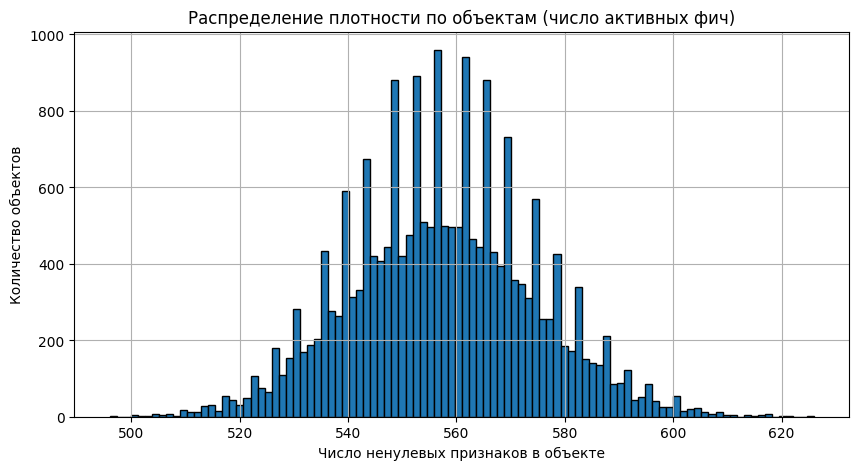

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(nonzero_per_row, bins=100, edgecolor='black')
plt.xlabel("Число ненулевых признаков в объекте")
plt.ylabel("Количество объектов")
plt.title("Распределение плотности по объектам (число активных фич)")
plt.grid(True)
plt.show()

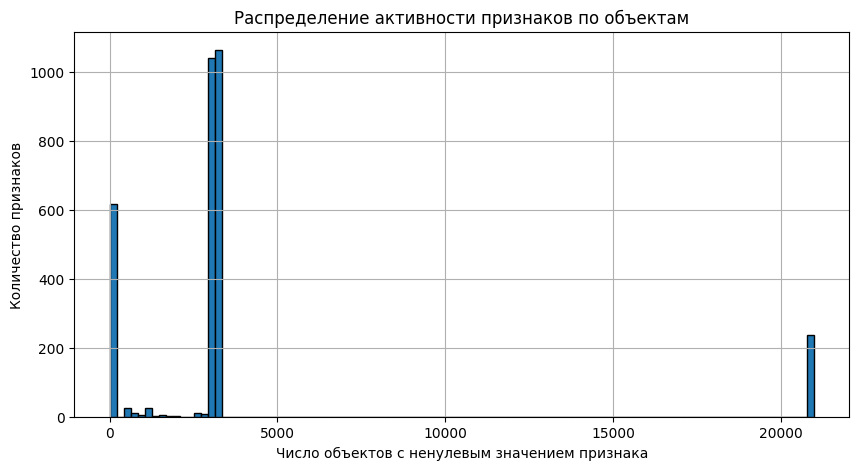

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(nonzero_per_col, bins=100, edgecolor='black')
plt.xlabel("Число объектов с ненулевым значением признака")
plt.ylabel("Количество признаков")
plt.title("Распределение активности признаков по объектам")
plt.grid(True)
plt.show()


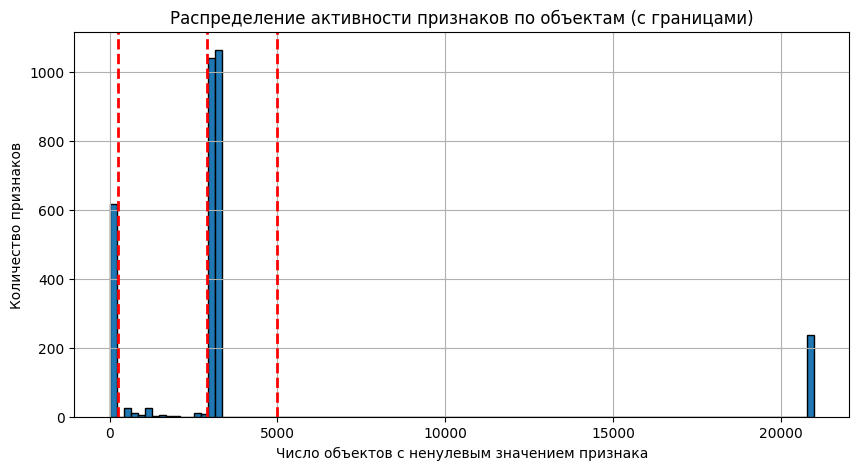

In [8]:
boundaries = [250, 2900, 5000]

plt.figure(figsize=(10, 5))
plt.hist(nonzero_per_col, bins=100, edgecolor='black')
for b in boundaries:
    plt.axvline(x=b, color='red', linestyle='--', linewidth=2)
plt.xlabel("Число объектов с ненулевым значением признака")
plt.ylabel("Количество признаков")
plt.title("Распределение активности признаков по объектам (с границами)")
plt.grid(True)
plt.show()

<250 - те самые 616 нулевых признаков, кокнем их

In [9]:
def compute_stats(matrix, label="Полный датасет"):
    dense = matrix.toarray()
    nonzero_vals = dense[dense != 0]
    pos_vals = nonzero_vals[nonzero_vals > 0]
    neg_vals = nonzero_vals[nonzero_vals < 0]
    
    stats = {
        "Датасет": label,
        "Кол-во элементов": dense.size,
        "Доля ненулевых": round(np.count_nonzero(dense) / dense.size, 4),
        "Кол-во положительных": np.count_nonzero(pos_vals),
        "Доля положительных": round(np.count_nonzero(pos_vals) / dense.size, 4),
        "Кол-во отрицательных": np.count_nonzero(neg_vals),
        "Доля отрицательных": round(np.count_nonzero(neg_vals) / dense.size, 4),
        "Среднее (все)": round(np.mean(dense), 4),
        "Среднее (ненулевые)": round(np.mean(nonzero_vals), 4),
        "Среднее (положительные)": round(np.mean(pos_vals), 4),
        "Среднее (отрицательные)": round(np.mean(neg_vals), 4),
        "Медиана (все)": round(np.median(dense), 4),
        "Медиана (ненулевые)": round(np.median(nonzero_vals), 4)
    }
    return stats

In [10]:
nonzero_cols_mask = nonzero_per_col != 0
train_cleaned = train[:, nonzero_cols_mask]

In [11]:
new_nonzero_per_col = np.diff(train_cleaned.tocsc().indptr)

group_indices = {
    "Нечастые (251–2900)": np.where((new_nonzero_per_col > boundaries[0]) & (new_nonzero_per_col <= boundaries[1]))[0],
    "Частые (2901–5000)": np.where((new_nonzero_per_col > boundaries[1]) & (new_nonzero_per_col <= boundaries[2]))[0],
    "Постоянные (>5000)": np.where(new_nonzero_per_col > boundaries[2])[0]
}

for key, value in group_indices.items():
    print(len(value))

91
2106
236


In [12]:
cleaned_stats = compute_stats(train_cleaned, "Очищенный датасет")
df_stats_cleaned = pd.DataFrame([cleaned_stats])

for name, indices in group_indices.items():
    subset = train_cleaned[:, indices]
    stats = compute_stats(subset, name)
    df_stats_cleaned = pd.concat([df_stats_cleaned, pd.DataFrame([stats])], ignore_index=True)

df_stats_cleaned

,Датасет,Кол-во элементов,Доля ненулевых,Кол-во положительных,Доля положительных,Кол-во отрицательных,Доля отрицательных,Среднее (все),Среднее (ненулевые),Среднее (положительные),Среднее (отрицательные),Медиана (все),Медиана (ненулевые)
0,Очищенный датасет,51093000,0.2291,6366551,0.1246,5337970,0.1045,40.2720,175.7970,326.4657,-3.9044,0.0000,0.1754
1,Нечастые (251–2900),1911000,0.0587,54830,0.0287,57252,0.0300,-0.1370,-2.3357,13.9319,-17.9151,0.0000,-0.0774
2,Частые (2901–5000),44226000,0.1501,4082853,0.0923,2553586,0.0577,46.5759,310.3874,507.1168,-4.1574,0.0000,0.3927
3,Постоянные (>5000),4956000,1.0000,2228868,0.4497,2727132,0.5503,-0.4008,-0.4008,3.2363,-3.3733,-0.5325,-0.5325


In [13]:
train_sign = train_cleaned.copy()
train_sign.data = np.sign(train_sign.data)

# вычисление статистик по строкам
def row_sign_stats(matrix, label):
    signs = matrix.toarray()
    pos_counts = (signs == 1).sum(axis=1)
    neg_counts = (signs == -1).sum(axis=1)
    total_counts = (signs != 0).sum(axis=1)
    ratio_pos_neg = np.divide(pos_counts, neg_counts, out=np.zeros_like(pos_counts, dtype=float), where=neg_counts != 0)

    return pd.DataFrame({
        "Датасет": label,
        "Положительных": pos_counts,
        "Отрицательных": neg_counts,
        "Всего ненулевых": total_counts,
        "Отношение + к -": ratio_pos_neg
    })

def summarized_sign_stats(matrix, label):
    df = row_sign_stats(matrix, label)
    return {
        "Датасет": label,
        "Среднее положительных": np.round(df["Положительных"].mean(), 4),
        "Среднее отрицательных": np.round(df["Отрицательных"].mean(), 4),
        "Среднее ненулевых": np.round(df["Всего ненулевых"].mean(), 4),
        "Среднее отношения + к -": np.round(df["Отношение + к -"].mean(), 4),
    }

# собираем всё
summary_stats = [summarized_sign_stats(train_sign, "Очищенный датасет")]
for name, indices in group_indices.items():
    subset = train_cleaned[:, indices]
    subset = subset[:, np.where(np.diff(subset.tocsc().indptr) > 0)[0]]  # удаляем пустые
    subset_sign = subset.copy()
    subset_sign.data = np.sign(subset_sign.data)
    summary_stats.append(summarized_sign_stats(subset_sign, name))

df_summary = pd.DataFrame(summary_stats)
df_summary


,Датасет,Среднее положительных,Среднее отрицательных,Среднее ненулевых,Среднее отношения + к -
0,Очищенный датасет,303.1691,254.1890,557.3581,1.1962
1,Нечастые (251–2900),2.6110,2.7263,5.3372,0.7841
2,Частые (2901–5000),194.4216,121.5993,316.0209,1.6124
3,Постоянные (>5000),106.1366,129.8634,236.0000,0.8209


промежуточные итоги анализа: все строки достаточно плотные, пустышек нет
два похожих нормальных распределения "ненулей" по строкам, явного разделения нет..
зато получилось разделить распределение "ненулей" по признакам: "нечастые", "частые", "постоянные"
плюс распределение положительных и отрицательных признаков несимметрично внутри подгрупп: в "частых" признаках положительных примерно в 1.5 раза больше, чем отрицательных, а в "постоянных" признаках наоборот, отрицательных больше

ниже создадим "знаковые" признаки на основании наших данных

In [14]:
aggregated_features = pd.DataFrame()

# общие агрегаты

# количество ненулевых, положительных и отрицательных по всей матрице
dense_sign = train_sign.toarray()

total_nonzero = (dense_sign != 0).sum(axis=1)
total_positive = (dense_sign == 1).sum(axis=1)
total_negative = (dense_sign == -1).sum(axis=1)
pos_to_neg_ratio = np.divide(
    total_positive, total_negative, 
    out=np.zeros_like(total_positive, dtype=float), 
    where=total_negative != 0
)

aggregated_features["total_nonzero"] = total_nonzero
aggregated_features["total_positive"] = total_positive
aggregated_features["total_negative"] = total_negative
aggregated_features["pos_to_neg_ratio"] = pos_to_neg_ratio

# агрегаты по группам признаков

for group_name, feature_indices in group_indices.items():
    group_matrix = train_cleaned[:, feature_indices]
    group_sign = group_matrix.copy()
    group_sign.data = np.sign(group_sign.data)
    dense_group_sign = group_sign.toarray()
    
    group_nonzero = (dense_group_sign != 0).sum(axis=1)
    group_positive = (dense_group_sign == 1).sum(axis=1)
    group_negative = (dense_group_sign == -1).sum(axis=1)
    group_pos_to_neg_ratio = np.divide(
        group_positive, group_negative, 
        out=np.zeros_like(group_positive, dtype=float), 
        where=group_negative != 0
    )

    prefix = group_name.replace(" ", "_").replace("(", "").replace(")", "").replace("–", "_").replace(">", "gt").replace("<", "lt")
    
    aggregated_features[f"{prefix}_nonzero"] = group_nonzero
    aggregated_features[f"{prefix}_positive"] = group_positive
    aggregated_features[f"{prefix}_negative"] = group_negative
    aggregated_features[f"{prefix}_pos_to_neg_ratio"] = group_pos_to_neg_ratio

aggregated_features.head(20)

,total_nonzero,total_positive,total_negative,pos_to_neg_ratio,Нечастые_251_2900_nonzero,Нечастые_251_2900_positive,Нечастые_251_2900_negative,Нечастые_251_2900_pos_to_neg_ratio,Частые_2901_5000_nonzero,Частые_2901_5000_positive,Частые_2901_5000_negative,Частые_2901_5000_pos_to_neg_ratio,Постоянные_gt5000_nonzero,Постоянные_gt5000_positive,Постоянные_gt5000_negative,Постоянные_gt5000_pos_to_neg_ratio
0,541,291,250,1.164000,0,0,0,0.000000,305,187,118,1.584746,236,104,132,0.787879
1,547,296,251,1.179283,1,1,0,0.000000,310,189,121,1.561983,236,106,130,0.815385
2,564,299,265,1.128302,3,1,2,0.500000,325,186,139,1.338129,236,112,124,0.903226
3,547,301,246,1.223577,0,0,0,0.000000,311,187,124,1.508065,236,114,122,0.934426
4,572,305,267,1.142322,15,9,6,1.500000,321,194,127,1.527559,236,102,134,0.761194
5,561,322,239,1.347280,15,10,5,2.000000,310,200,110,1.818182,236,112,124,0.903226
6,563,316,247,1.279352,12,7,5,1.400000,315,206,109,1.889908,236,103,133,0.774436
7,568,321,247,1.299595,2,1,1,1.000000,330,212,118,1.796610,236,108,128,0.843750
8,560,330,230,1.434783,2,1,1,1.000000,322,208,114,1.824561,236,121,115,1.052174
9,537,290,247,1.174089,1,0,1,0.000000,300,188,112,1.678571,236,102,134,0.761194


In [15]:
aggregated_features.describe().T

,count,mean,std,min,25%,50%,75%,max
total_nonzero,21000.0,557.358143,16.999065,496.000000,546.000000,557.000000,569.000000,626.000000
total_positive,21000.0,303.169095,14.736705,249.000000,293.000000,303.000000,313.000000,369.000000
total_negative,21000.0,254.189048,12.459918,206.000000,246.000000,254.000000,263.000000,299.000000
pos_to_neg_ratio,21000.0,1.196225,0.091887,0.909747,1.133094,1.192157,1.256000,1.700461
Нечастые_251_2900_nonzero,21000.0,5.337238,4.966441,0.000000,1.000000,4.000000,9.000000,27.000000
Нечастые_251_2900_positive,21000.0,2.610952,2.845310,0.000000,0.000000,2.000000,4.000000,17.000000
Нечастые_251_2900_negative,21000.0,2.726286,2.646954,0.000000,1.000000,2.000000,4.000000,17.000000
Нечастые_251_2900_pos_to_neg_ratio,21000.0,0.784069,0.996225,0.000000,0.000000,0.500000,1.000000,13.000000
Частые_2901_5000_nonzero,21000.0,316.020905,16.231573,255.000000,305.000000,316.000000,327.000000,387.000000
Частые_2901_5000_positive,21000.0,194.421571,13.205250,148.000000,185.000000,194.000000,203.000000,260.000000


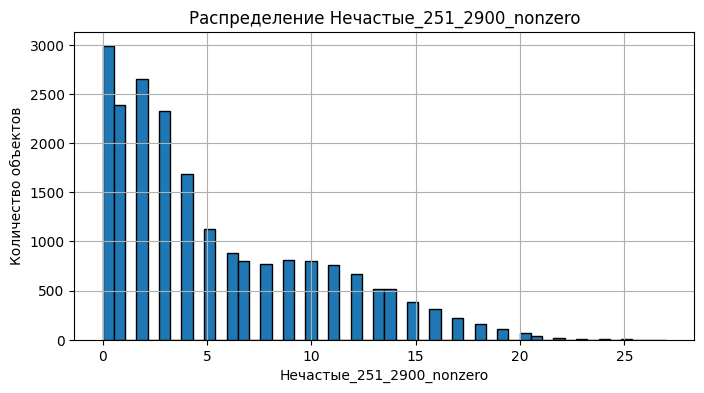

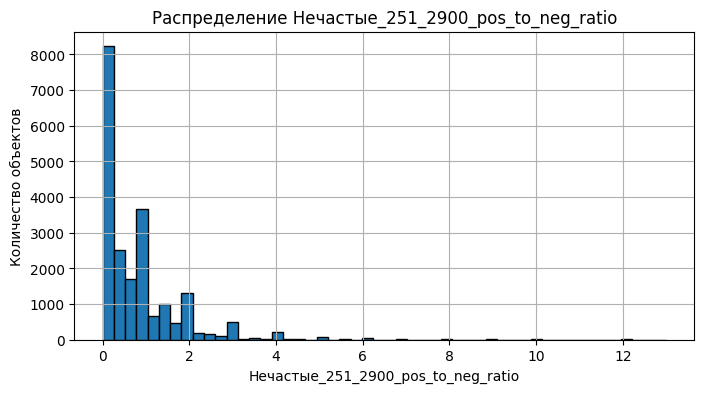

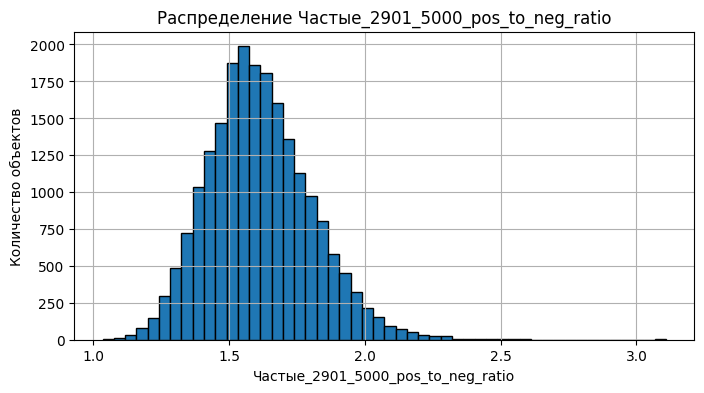

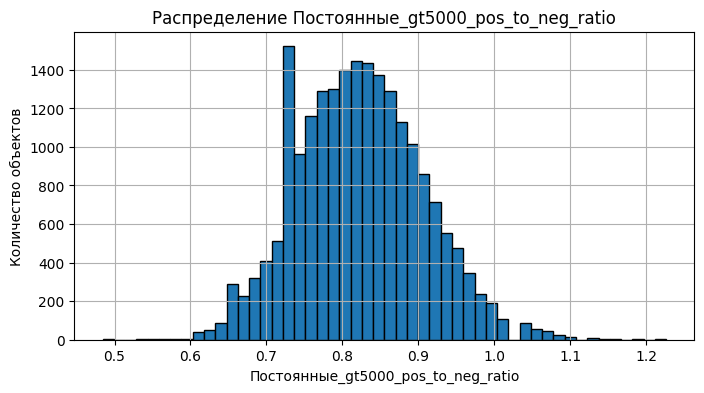

In [16]:
features_to_plot = [
    "Нечастые_251_2900_nonzero",
    "Нечастые_251_2900_pos_to_neg_ratio",
    "Частые_2901_5000_pos_to_neg_ratio",
    "Постоянные_gt5000_pos_to_neg_ratio"
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    plt.hist(aggregated_features[feature], bins=50, edgecolor='black')
    plt.title(f"Распределение {feature}")
    plt.xlabel(feature)
    plt.ylabel("Количество объектов")
    plt.grid(True)
    plt.show()


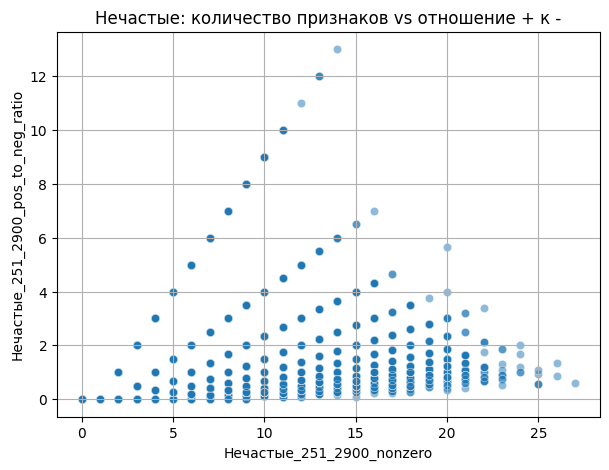

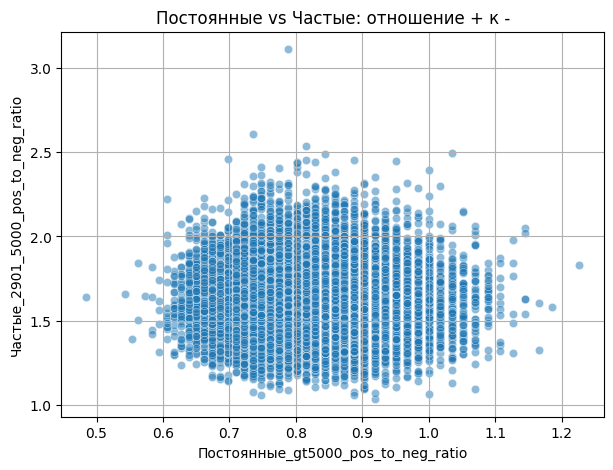

In [17]:
# 1. Нечастые признаки: количество vs отношение знаков
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=aggregated_features["Нечастые_251_2900_nonzero"], 
    y=aggregated_features["Нечастые_251_2900_pos_to_neg_ratio"],
    alpha=0.5
)
plt.title("Нечастые: количество признаков vs отношение + к -")
plt.grid(True)
plt.show()

# 2. Постоянные и частые признаки: отношение знаков
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=aggregated_features["Постоянные_gt5000_pos_to_neg_ratio"], 
    y=aggregated_features["Частые_2901_5000_pos_to_neg_ratio"],
    alpha=0.5
)
plt.title("Постоянные vs Частые: отношение + к -")
plt.grid(True)
plt.show()


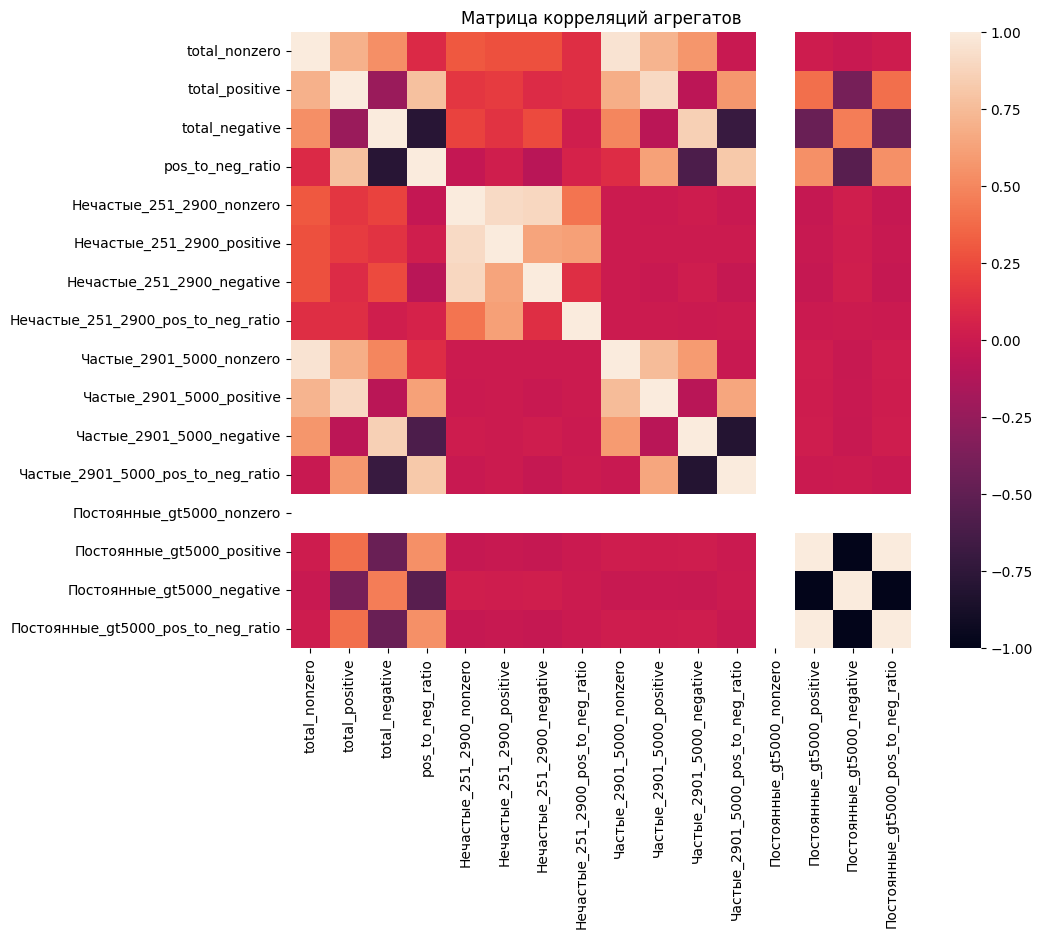

In [18]:
corr = aggregated_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr)
plt.title("Матрица корреляций агрегатов")
plt.show()

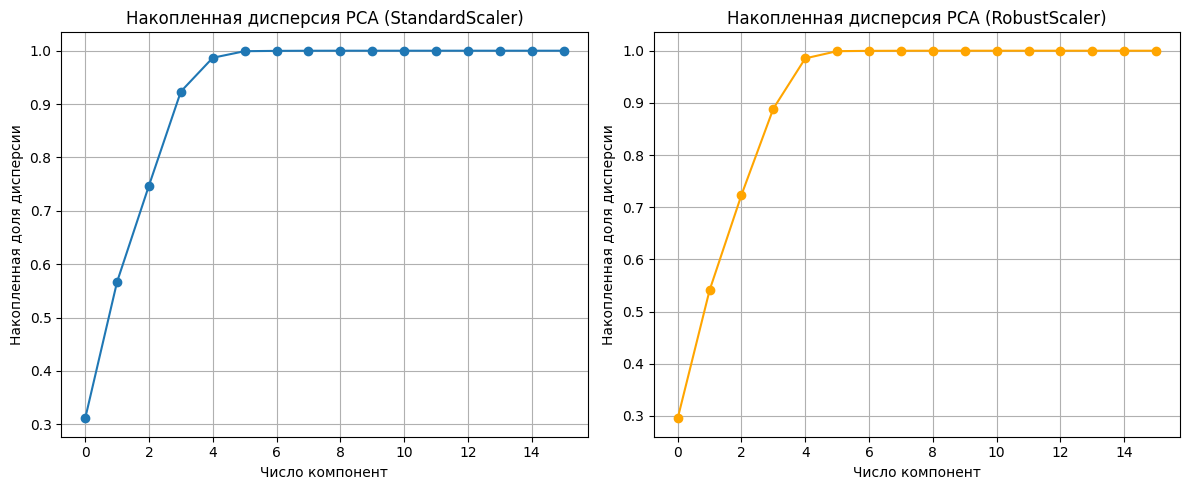

In [19]:
# 1. Масштабирование: StandardScaler
scaler_standard = StandardScaler()
X_standard_scaled = scaler_standard.fit_transform(aggregated_features)

# 2. Масштабирование: RobustScaler
scaler_robust = RobustScaler()
X_robust_scaled = scaler_robust.fit_transform(aggregated_features)

# 3. PCA для StandardScaler
pca_standard = PCA()
X_pca_standard = pca_standard.fit_transform(X_standard_scaled)

# 4. PCA для RobustScaler
pca_robust = PCA()
X_pca_robust = pca_robust.fit_transform(X_robust_scaled)

# 5. Построение графиков

plt.figure(figsize=(12, 5))

# Накопленная дисперсия для StandardScaler
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca_standard.explained_variance_ratio_), marker='o')
plt.title('Накопленная дисперсия PCA (StandardScaler)')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.grid(True)

# Накопленная дисперсия для RobustScaler
plt.subplot(1, 2, 2)
plt.plot(np.cumsum(pca_robust.explained_variance_ratio_), marker='o', color='orange')
plt.title('Накопленная дисперсия PCA (RobustScaler)')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.grid(True)

plt.tight_layout()
plt.show()


In [20]:
cumulative_variance = np.cumsum(pca_standard.explained_variance_ratio_)
n_components_90 = np.searchsorted(cumulative_variance, 0.90) + 1

print(f"Число компонент для покрытия 90% дисперсии: {n_components_90}")


Число компонент для покрытия 90% дисперсии: 4


In [21]:
# X_pca_4 = X_pca_standard[:, :4]

# best_score = -1
# best_n_clusters = None

# for n_clusters in range(5, 31):
#     clustering = AgglomerativeClustering(n_clusters=n_clusters)
#     labels = clustering.fit_predict(X_pca_4)
    
#     score = silhouette_score(X_pca_4, labels)
#     print(f"Кластеры: {n_clusters}, силуэт-скор: {score:.4f}")
    
#     if score > best_score:
#         best_score = score
#         best_n_clusters = n_clusters

# print(f"\nЛучший результат: {best_n_clusters} кластеров, силуэт-скор {best_score:.4f}")


In [22]:
# # 1. Данные: наши 4 PCA-компоненты
# X_pca_4 = X_pca_standard[:, :4]

# # 2. Строим k-ближайших соседей граф
# k = 15
# knn_graph = kneighbors_graph(X_pca_4, n_neighbors=k, include_self=False)

# # 3. Перебор количества кластеров
# best_score = -1
# best_n_clusters = None

# for n_clusters in range(5, 21):
#     spectral = SpectralClustering(
#         n_clusters=n_clusters, 
#         affinity='precomputed_nearest_neighbors',
#         assign_labels='kmeans',
#         random_state=42,
#         n_neighbors=k
#     )
#     labels = spectral.fit_predict(knn_graph)
    
#     score = silhouette_score(X_pca_4, labels)
#     print(f"Кластеры: {n_clusters}, силуэт-скор: {score:.4f}")
    
#     if score > best_score:
#         best_score = score
#         best_n_clusters = n_clusters

# print(f"\nЛучший результат: {best_n_clusters} кластеров, силуэт-скор {best_score:.4f}")


In [23]:
# # 1. Данные: агрегаты без PCA
# X_raw = aggregated_features.values

# # 2. Строим k-ближайших соседей граф
# k = 15
# knn_graph_raw = kneighbors_graph(X_raw, n_neighbors=k, include_self=False)

# # 3. Перебор количества кластеров
# best_score = -1
# best_n_clusters = None

# for n_clusters in range(4, 11):
#     spectral = SpectralClustering(
#         n_clusters=n_clusters, 
#         affinity='precomputed',
#         assign_labels='kmeans',
#         random_state=42
#     )
#     labels = spectral.fit_predict(knn_graph_raw)
    
#     score = silhouette_score(X_raw, labels)
#     print(f"Кластеры: {n_clusters}, силуэт-скор: {score:.4f}")
    
#     if score > best_score:
#         best_score = score
#         best_n_clusters = n_clusters

# print(f"\nЛучший результат: {best_n_clusters} кластеров, силуэт-скор {best_score:.4f}")


In [24]:
# k_list = [10, 15, 20, 25, 30]
# n_clusters_range = range(4, 11)

# best_overall_score = -1
# best_k = None
# best_n_clusters = None

# for k in k_list:
#     print(f"\n==== Перебор для k = {k} ====")
#     knn_graph_raw = kneighbors_graph(X_raw, n_neighbors=k, include_self=False)

#     for n_clusters in n_clusters_range:
#         spectral = SpectralClustering(
#             n_clusters=n_clusters,
#             affinity='precomputed',
#             assign_labels='kmeans',
#             random_state=42
#         )
#         labels = spectral.fit_predict(knn_graph_raw)

#         score = silhouette_score(X_raw, labels)
#         print(f"k={k}, кластеры={n_clusters}, силуэт-скор={score:.4f}")

#         if score > best_overall_score:
#             best_overall_score = score
#             best_k = k
#             best_n_clusters = n_clusters

# print(f"\nЛучший результат: k={best_k}, кластеры={best_n_clusters}, силуэт-скор={best_overall_score:.4f}")


In [25]:
# knn_graph_raw = kneighbors_graph(X_raw, n_neighbors=best_k, include_self=False)

# spectral = SpectralClustering(
#     n_clusters=best_n_clusters,
#     affinity='precomputed',
#     assign_labels='kmeans',
#     random_state=42
# )
# labels = spectral.fit_predict(knn_graph_raw)


# submission = pd.DataFrame({
#     'ID': np.arange(len(labels)),
#     'TARGET': labels
# })

# submission.to_csv('spectral_submission.csv', index=False)


попробуем отобрать "вещественные" агрегаты на основании наших данных

In [ ]:
def calculate_density(matrix):
    return (matrix != 0).sum(axis=1).A1

def calculate_sign_statistics(matrix_sign, indices):
    subset = matrix_sign[:, indices]
    pos_counts = (subset.toarray() == 1).sum(axis=1)
    neg_counts = (subset.toarray() == -1).sum(axis=1)
    return pos_counts, neg_counts

def calculate_log_statistics(matrix_log, indices):
    subset = matrix_log[:, indices]
    dense = subset.toarray()
    dense[dense == 0] = np.nan
    mean_vals = np.nanmean(dense, axis=1)
    sum_vals = np.nansum(dense, axis=1)
    std_vals = np.nanstd(dense, axis=1)
    return mean_vals, sum_vals, std_vals

def sparse_signed_log1p(sparse_matrix):
    result = sparse_matrix.copy()
    result.data = np.sign(result.data) * np.log1p(np.abs(result.data))
    return result


In [ ]:
def build_feature_table(train_cleaned, train_cleaned_log, 
                        selected_indices_rare, selected_indices_frequent, 
                        louvain_labels_signs):

    # плотности
    density = calculate_density(train_cleaned)
    density_rare = calculate_density(train_cleaned[:, selected_indices_rare])
    
    # знаковая матрица
    train_sign = train_cleaned.copy()
    train_sign.data = np.sign(train_sign.data)
    
    pos_counts_rare, neg_counts_rare = calculate_sign_statistics(train_sign, selected_indices_rare)
    
    # средний знак по частым
    sign_frequent = train_sign[:, selected_indices_frequent].toarray()
    mean_sign_frequent = np.nanmean(sign_frequent, axis=1)
    
    # логарифмические агрегаты
    mean_value_frequent, sum_value_frequent, std_value_frequent = calculate_log_statistics(
        train_cleaned_log, selected_indices_frequent
    )
    
    feature_df = pd.DataFrame({
        "louvain_signs_k20": louvain_labels_signs,
        "density": density,
        "density_rare": density_rare,
        "num_positive_rare": pos_counts_rare,
        "num_negative_rare": neg_counts_rare,
        "mean_sign_frequent": mean_sign_frequent,
        "mean_value_frequent": mean_value_frequent,
        "sum_value_frequent": sum_value_frequent,
        "std_value_frequent": std_value_frequent
    })

    return feature_df

In [28]:
train_cleaned_log = sparse_signed_log1p(train_cleaned)

new_nonzero_per_col_loged = np.diff(train_cleaned_log.tocsc().indptr)


group_indices_loged = {
    "Нечастые (251–2900)": np.where((new_nonzero_per_col_loged > boundaries[0]) & (new_nonzero_per_col <= boundaries[1]))[0],
    "Частые (2901–5000)": np.where((new_nonzero_per_col_loged > boundaries[1]) & (new_nonzero_per_col <= boundaries[2]))[0],
    "Постоянные (>5000)": np.where(new_nonzero_per_col_loged > boundaries[2])[0]
}

selected_indices_rare = group_indices_loged["Нечастые (251–2900)"]
selected_indices_frequent = group_indices_loged["Частые (2901–5000)"]
selected_indices_permanent = group_indices_loged["Постоянные (>5000)"]

selected_indices_loged = np.concatenate([selected_indices_rare, selected_indices_frequent, selected_indices_permanent])

train_subset_log = train_cleaned_log[:, selected_indices_loged]


In [29]:
def build_knn_graph(matrix, n_neighbors=20, metric="cosine"):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric=metric, n_jobs=-1)
    nbrs.fit(matrix)
    knn_graph = nbrs.kneighbors_graph(mode='connectivity')
    G = nx.from_scipy_sparse_array(knn_graph)
    return G

In [30]:
G_signs = build_knn_graph(train_subset_log, n_neighbors=20, metric="cosine")


In [31]:
def cluster_louvain(G):
    partition = community.best_partition(G)
    cluster_labels = np.array([partition[i] for i in range(len(partition))])
    return cluster_labels

In [32]:
louvain_labels_signs = cluster_louvain(G_signs)


In [33]:
feature_df = build_feature_table(
    train_cleaned=train_cleaned,
    train_cleaned_log=train_cleaned_log,
    selected_indices_rare=selected_indices_rare,
    selected_indices_frequent=selected_indices_frequent,
    louvain_labels_signs=louvain_labels_signs
)


In [34]:
feature_df.head(15)

,louvain_signs_k20,density,density_rare,num_positive_rare,num_negative_rare,mean_sign_frequent,mean_value_frequent,sum_value_frequent,std_value_frequent
0,0,541,0,0,0,0.032764,0.076612,23.366588,1.212983
1,1,547,1,1,0,0.032289,0.073332,22.733058,1.506401
2,2,564,3,1,2,0.022317,-0.119357,-38.791147,1.361971
3,3,547,0,0,0,0.029915,-0.010575,-3.288678,1.325152
4,4,572,15,9,6,0.031814,0.051955,16.677485,1.188278
5,5,561,15,10,5,0.042735,0.174051,53.955691,1.576040
6,0,563,12,7,5,0.046059,0.067131,21.146415,1.093707
7,5,568,2,1,1,0.044634,0.068124,22.480884,1.389863
8,1,560,2,1,1,0.044634,0.016074,5.175756,1.178431
9,0,537,1,0,1,0.036087,-0.037629,-11.288778,1.109693


In [35]:
# scaler = StandardScaler()
# features_to_scale = ["density", "density_rare", "num_positive_rare", "num_negative_rare"]
# feature_df_scaled = feature_df.copy()
# feature_df_scaled[features_to_scale] = scaler.fit_transform(feature_df_scaled[features_to_scale])


In [36]:
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_quantiled = qt.fit_transform(feature_df.drop(columns=["louvain_signs_k20"]))


In [37]:
louvain_cat = feature_df["louvain_signs_k20"].astype("category")

ohe = OneHotEncoder(sparse_output=False, drop=None)
louvain_ohe = ohe.fit_transform(louvain_cat.values.reshape(-1, 1))


In [38]:
X_final = np.hstack([X_quantiled, louvain_ohe])


In [39]:
X_final.shape

(21000, 28)

In [40]:
qt_agg = QuantileTransformer(output_distribution="normal", random_state=42)
agg_scaled = qt_agg.fit_transform(aggregated_features)

In [41]:
aggregated_features.shape

(21000, 16)

In [42]:
agg_scaled.shape

(21000, 16)

In [43]:
X_full = np.hstack([
    X_quantiled,     # 19 нормализованных признаков
    louvain_ohe,     # 9 бинарных кластеров
    agg_scaled       # 16 нормализованных aggregated-фичей
])

In [44]:
X_full.shape

(21000, 44)

In [45]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom'
)

labels = clusterer.fit_predict(X_full)

In [46]:
import numpy as np

n_clusters = len(np.unique(labels))
n_noise = np.sum(labels == -1)

print(f"Кластеров: {n_clusters} (из них шумом помечены: {n_noise})")


Кластеров: 5 (из них шумом помечены: 1)


In [47]:
# submission = pd.DataFrame({
#     'ID': np.arange(len(labels)),
#     'TARGET': labels
# })

# submission.to_csv('hdbscan_custom_features_submission.csv', index=False)

In [48]:
features_to_scale = ["density", "density_rare", "num_positive_rare", "num_negative_rare"]
scaler = StandardScaler()
feature_df_scaled = feature_df.copy()
feature_df_scaled[features_to_scale] = scaler.fit_transform(feature_df_scaled[features_to_scale])


In [ ]:
agg_additional = aggregated_features[[
    "total_nonzero",
    "pos_to_neg_ratio",
    "Частые_2901_5000_pos_to_neg_ratio"
]].copy()

scaler_extra = StandardScaler()
agg_scaled = scaler_extra.fit_transform(agg_additional)

X_base = feature_df_scaled[[
    "density", "density_rare", "num_positive_rare", "num_negative_rare",
    "mean_sign_frequent", "mean_value_frequent", "sum_value_frequent", "std_value_frequent"
]].values

X_augmented = np.hstack([X_base, agg_scaled])


In [50]:
X_augmented.shape

(21000, 11)

In [51]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    cluster_selection_epsilon=0.3
)

hdbscan_labels = clusterer.fit_predict(X_augmented)


In [52]:
n_clusters = len(np.unique(hdbscan_labels))
n_noise = np.sum(hdbscan_labels == -1)

print(f"Кластеров: {n_clusters} (из них шумом помечены: {n_noise})")

Кластеров: 3 (из них шумом помечены: 2832)


In [53]:
# submission = pd.DataFrame({
#     'ID': np.arange(len(labels)),
#     'TARGET': labels
# })

# submission.to_csv('hdbscan_custom_features_submission.csv', index=False)

In [ ]:
feature_names = [
    "density", "density_rare", "num_positive_rare", "num_negative_rare",
    "mean_sign_frequent", "mean_value_frequent", "sum_value_frequent", "std_value_frequent"
]

# разобьём признаки на 4 квантили и посчитаем silhouette score
silhouette_results = []

for feature in feature_names:
    values = feature_df_scaled[feature].values.reshape(-1, 1)
    
    # биннинг по квантилям
    discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
    try:
        binned = discretizer.fit_transform(values).flatten()
        score = silhouette_score(values, binned)
        silhouette_results.append({"feature": feature, "silhouette_score": score})
    except Exception as e:
        silhouette_results.append({"feature": feature, "silhouette_score": np.nan, "error": str(e)})

silhouette_df = pd.DataFrame(silhouette_results).sort_values(by="silhouette_score", ascending=False)


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [57]:
aggregated_features.shape

(21000, 16)

In [55]:
silhouette_df

,feature,silhouette_score
3,num_negative_rare,0.691609
2,num_positive_rare,0.598766
1,density_rare,0.535588
7,std_value_frequent,0.505078
4,mean_sign_frequent,0.482893
0,density,0.477932
6,sum_value_frequent,0.473441
5,mean_value_frequent,0.473394


In [58]:
agg_scaled = qt_agg.fit_transform(aggregated_features)
agg_scaled_df = pd.DataFrame(agg_scaled, columns=aggregated_features.columns)
agg_scaled.shape

(21000, 16)

In [59]:
agg_scaled_df = pd.DataFrame(agg_scaled, columns=aggregated_features.columns)

core_features = [
    "density", "density_rare", "num_positive_rare", "num_negative_rare",
    "mean_sign_frequent", "mean_value_frequent", "sum_value_frequent", "std_value_frequent"
]

X_core = feature_df_scaled[core_features].copy()
full_scaled_features = pd.concat([X_core.reset_index(drop=True), agg_scaled_df.reset_index(drop=True)], axis=1)


In [61]:
full_scaled_features.shape

(21000, 24)

In [62]:
full_scaled_features.head()

,density,density_rare,num_positive_rare,num_negative_rare,mean_sign_frequent,mean_value_frequent,sum_value_frequent,std_value_frequent,total_nonzero,total_positive,...,Нечастые_251_2900_negative,Нечастые_251_2900_pos_to_neg_ratio,Частые_2901_5000_nonzero,Частые_2901_5000_positive,Частые_2901_5000_negative,Частые_2901_5000_pos_to_neg_ratio,Постоянные_gt5000_nonzero,Постоянные_gt5000_positive,Постоянные_gt5000_negative,Постоянные_gt5000_pos_to_neg_ratio
0,-0.962320,-1.074686,-0.917656,-1.029995,0.032764,0.076612,23.366588,1.212983,-0.949547,-0.824933,...,-5.199338,-5.199338,-0.662724,-0.555462,-0.312376,-0.090452,-5.199338,-0.357496,0.357496,-0.357496
1,-0.609351,-0.873330,-0.566192,-1.029995,0.032289,0.073332,22.733058,1.506401,-0.593940,-0.476619,...,-5.199338,-5.199338,-0.353487,-0.404717,-0.025094,-0.218773,-5.199338,-0.015055,0.015055,-0.015055
2,0.390728,-0.470617,-0.566192,-0.274392,0.022317,-0.119357,-38.791147,1.361971,0.408805,-0.267884,...,0.020074,-0.055229,0.571638,-0.633317,1.620592,-1.580377,-5.199338,1.025123,-1.025123,1.025123
3,-0.609351,-1.074686,-0.917656,-1.029995,0.029915,-0.010575,-3.288678,1.325152,-0.593940,-0.137177,...,-5.199338,-5.199338,-0.293986,-0.555462,0.265284,-0.532190,-5.199338,1.365257,-1.365257,1.365257
4,0.861354,1.945657,2.245520,1.236815,0.031814,0.051955,16.677485,1.188278,0.880888,0.140977,...,1.102440,0.951518,0.322932,-0.010037,0.532190,-0.414267,-5.199338,-0.705530,0.705530,-0.705530


In [63]:
full_scaled_features.describe().T

,count,mean,std,min,25%,50%,75%,max
density,21000.0,-4.955190e-16,1.000024,-3.609587,-0.668179,-0.021069,0.684869,4.038075
density_rare,21000.0,4.872293e-17,1.000024,-1.074686,-0.873330,-0.269261,0.737520,4.361932
num_positive_rare,21000.0,4.229421e-17,1.000024,-0.917656,-0.917656,-0.214728,0.488200,5.057231
num_negative_rare,21000.0,-1.911698e-17,1.000024,-1.029995,-0.652194,-0.274392,0.481211,5.392634
mean_sign_frequent,21000.0,3.457846e-02,0.008427,0.002374,0.028965,0.034663,0.040361,0.082146
mean_value_frequent,21000.0,1.717920e-02,0.077828,-0.279725,-0.036101,0.014777,0.067660,0.384120
sum_value_frequent,21000.0,5.425267e+00,24.561772,-84.756675,-11.342443,4.667876,21.379835,129.448291
std_value_frequent,21000.0,1.321995e+00,0.186503,0.840894,1.171894,1.300572,1.445636,2.112335
total_nonzero,21000.0,9.022894e-03,1.005938,-5.199338,-0.654930,-0.002509,0.708752,5.199338
total_positive,21000.0,-2.356193e-03,1.004826,-5.199338,-0.692715,0.006273,0.672129,5.199338


In [ ]:
qt_cols = [
    'sum_value_frequent', 'mean_value_frequent', 'std_value_frequent',
    'Частые_2901_5000_positive', 'Частые_2901_5000_negative', 'Частые_2901_5000_nonzero',
    'Нечастые_251_2900_positive', 'Нечастые_251_2900_negative', 'Нечастые_251_2900_nonzero'
]

other_cols = [col for col in full_scaled_features.columns if col not in qt_cols]

qt = QuantileTransformer(output_distribution="normal", random_state=42)
qt_scaled = pd.DataFrame(qt.fit_transform(full_scaled_features[qt_cols]), columns=qt_cols)

scaler = StandardScaler()
std_scaled = pd.DataFrame(scaler.fit_transform(full_scaled_features[other_cols]), columns=other_cols)

full_rescaled_features = pd.concat([qt_scaled, std_scaled], axis=1)

full_rescaled_features.describe().T

,count,mean,std,min,25%,50%,75%,max
sum_value_frequent,21000.0,-2.067565e-02,0.998592,-5.199338,-0.686009,-0.031262,0.654820,5.199338
mean_value_frequent,21000.0,-2.050281e-02,0.998013,-5.199338,-0.687626,-0.031011,0.652594,5.199338
std_value_frequent,21000.0,-6.029317e-03,1.003683,-5.199338,-0.686640,-0.002646,0.671400,5.199338
Частые_2901_5000_positive,21000.0,-6.267619e-03,0.998889,-5.199338,-0.713599,-0.010037,0.651824,5.199338
Частые_2901_5000_negative,21000.0,2.019536e-02,0.998112,-5.199338,-0.689529,-0.025094,0.716839,5.199338
Частые_2901_5000_nonzero,21000.0,8.070644e-03,1.003419,-5.199338,-0.662724,0.013801,0.694311,5.199338
Нечастые_251_2900_positive,21000.0,-1.148438e+00,2.631667,-5.199338,-5.199338,0.104318,0.662724,5.199338
Нечастые_251_2900_negative,21000.0,-8.596121e-01,2.421646,-5.199338,-0.450080,0.020074,0.619578,5.199338
Нечастые_251_2900_nonzero,21000.0,-5.098502e-01,2.047317,-5.199338,-0.844485,0.086674,0.721714,5.199338
density,21000.0,-3.417372e-17,1.000024,-3.609587,-0.668179,-0.021069,0.684869,4.038075


In [65]:
non_constant_columns = full_scaled_features.loc[:, full_scaled_features.std() > 1e-6]


In [66]:
non_constant_columns.shape

(21000, 23)

In [ ]:
features = full_scaled_features.columns.tolist()

results = []

# прогоним по одиночным признакам
for feature in features:
    X = full_scaled_features[[feature]].values
    clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
    labels = clusterer.fit_predict(X)
    
    if len(set(labels)) > 1 and len(set(labels)) < len(X):
        sil_score = silhouette_score(X, labels)
    else:
        sil_score = -1
    
    noise_pct = np.sum(labels == -1) / len(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    results.append({
        "type": "single",
        "features": (feature,),
        "n_clusters": n_clusters,
        "noise_pct": noise_pct,
        "silhouette": sil_score
    })

# прогоним по всем парам признаков
for f1, f2 in itertools.combinations(features, 2):
    X = full_scaled_features[[f1, f2]].values
    clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
    labels = clusterer.fit_predict(X)
    
    if len(set(labels)) > 1 and len(set(labels)) < len(X):
        sil_score = silhouette_score(X, labels)
    else:
        sil_score = -1
    
    noise_pct = np.sum(labels == -1) / len(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    results.append({
        "type": "pair",
        "features": (f1, f2),
        "n_clusters": n_clusters,
        "noise_pct": noise_pct,
        "silhouette": sil_score
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["n_clusters", "silhouette"], ascending=[True, False])
results_df

,type,features,n_clusters,noise_pct,silhouette
134,pair,"(mean_value_frequent, pos_to_neg_ratio)",2,0.009857,0.431391
167,pair,"(std_value_frequent, pos_to_neg_ratio)",2,0.027857,0.360715
130,pair,"(mean_value_frequent, std_value_frequent)",2,0.073952,0.302524
175,pair,"(std_value_frequent, Частые_2901_5000_pos_to_n...",2,0.073905,0.289031
229,pair,"(pos_to_neg_ratio, Частые_2901_5000_pos_to_neg...",2,0.091619,0.221904
...,...,...,...,...,...
199,pair,"(total_positive, Нечастые_251_2900_negative)",184,0.053952,0.507389
7,single,"(std_value_frequent,)",184,0.075381,0.377816
176,pair,"(std_value_frequent, Постоянные_gt5000_nonzero)",184,0.075381,0.377816
103,pair,"(num_negative_rare, Частые_2901_5000_positive)",185,0.047095,0.586234


In [77]:
results_df = results_df.sort_values(by=["silhouette", "n_clusters"], ascending=[False, True])
results_df.head(30)

,type,features,n_clusters,noise_pct,silhouette
260,pair,"(Нечастые_251_2900_negative, Постоянные_gt5000...",13,0.001667,0.999333
14,single,"(Нечастые_251_2900_negative,)",13,0.001667,0.999333
100,pair,"(num_negative_rare, Нечастые_251_2900_negative)",13,0.001667,0.999004
241,pair,"(Нечастые_251_2900_nonzero, Постоянные_gt5000_...",22,0.000048,0.998280
12,single,"(Нечастые_251_2900_nonzero,)",22,0.000048,0.998280
106,pair,"(num_negative_rare, Постоянные_gt5000_nonzero)",13,0.000333,0.998159
3,single,"(num_negative_rare,)",13,0.000333,0.998159
251,pair,"(Нечастые_251_2900_positive, Постоянные_gt5000...",14,0.000095,0.997868
13,single,"(Нечастые_251_2900_positive,)",14,0.000095,0.997868
57,pair,"(density_rare, Нечастые_251_2900_nonzero)",22,0.000048,0.997702


In [ ]:
X_all = full_scaled_features.copy()
feature_names = X_all.columns.tolist()

# параметры типа Beam Search
beam_width = 4
max_features = 10

# начальное состояние: все одиночные признаки
initial_states = []
for feature in feature_names:
    X = X_all[[feature]].values
    labels = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = np.sum(labels == -1) / len(labels)
    if n_clusters > 1:
        sil_score = silhouette_score(X, labels)
    else:
        sil_score = -1
    initial_states.append({
        "features": (feature,),
        "silhouette": sil_score,
        "n_clusters": n_clusters,
        "noise_pct": noise_pct
    })

# сортировка и выбор начального beam
beam = sorted(initial_states, key=lambda x: (-x['silhouette'], x['n_clusters']))[:beam_width]

# история всех состояний
all_states = beam.copy()

# а-ля Beam Search
for depth in tqdm(range(2, max_features + 1), desc="Beam Search"):
    new_candidates = []
    for state in beam:
        used = set(state["features"])
        for feat in feature_names:
            if feat not in used:
                new_feats = tuple(sorted(list(used | {feat})))
                if any(s["features"] == new_feats for s in all_states):
                    continue
                X = X_all[list(new_feats)].values
                labels = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(X)
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                noise_pct = np.sum(labels == -1) / len(labels)
                if n_clusters > 1:
                    sil_score = silhouette_score(X, labels)
                else:
                    sil_score = -1
                candidate = {
                    "features": new_feats,
                    "silhouette": sil_score,
                    "n_clusters": n_clusters,
                    "noise_pct": noise_pct
                }
                new_candidates.append(candidate)
                all_states.append(candidate)
    beam = sorted(new_candidates, key=lambda x: (x['silhouette'], -x['noise_pct'], x['n_clusters']), reverse=True)[:beam_width]

beam_feature_search = pd.DataFrame(all_states)
beam_feature_search

Beam Search: 100%|██████████| 9/9 [27:58<00:00, 186.47s/it]


,features,silhouette,n_clusters,noise_pct
0,"(Нечастые_251_2900_negative,)",0.999333,13,0.001667
1,"(Нечастые_251_2900_nonzero,)",0.998280,22,0.000048
2,"(num_negative_rare,)",0.998159,13,0.000333
3,"(Нечастые_251_2900_positive,)",0.997868,14,0.000095
4,"(density, Нечастые_251_2900_negative)",0.465943,163,0.022714
...,...,...,...,...
653,"(density_rare, mean_sign_frequent, mean_value_...",0.072849,124,0.070667
654,"(density_rare, mean_sign_frequent, mean_value_...",0.199871,73,0.051905
655,"(density_rare, mean_sign_frequent, mean_value_...",0.146949,160,0.075476
656,"(density_rare, mean_sign_frequent, mean_value_...",0.146949,160,0.075476


In [80]:
beam_feature_search["n_features"] = beam_feature_search["features"].apply(len)


In [83]:
beam_feature_search.sort_values(by=["silhouette"])

filtered = beam_feature_search[(beam_feature_search["n_clusters"] <= 22) & 
(beam_feature_search["n_features"] >= 3)].sort_values(by=["silhouette", "n_clusters", "n_features"],
ascending=[False, True, True])

filtered.head(40)

,features,silhouette,n_clusters,noise_pct,n_features
93,"(num_negative_rare, Нечастые_251_2900_negative...",0.999004,13,0.001667,3
134,"(density_rare, Нечастые_251_2900_nonzero, Пост...",0.997702,22,0.000048,3
96,"(sum_value_frequent, Нечастые_251_2900_negativ...",-0.247022,6,0.003095,3
200,"(density_rare, sum_value_frequent, Нечастые_25...",-0.508194,19,0.007333,4
139,"(sum_value_frequent, Нечастые_251_2900_nonzero...",-0.512366,19,0.007381,3


In [ ]:
selected_features = ['num_negative_rare', 'Нечастые_251_2900_negative', 'Постоянные_gt5000_nonzero']

X_best = full_scaled_features[selected_features].values

umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42, metric="euclidean")
X_umap = umap_model.fit_transform(X_best)

clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5, prediction_data=True)
labels = clusterer.fit_predict(X_umap)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct = np.sum(labels == -1) / len(labels)
sil_score = silhouette_score(X_umap, labels) if n_clusters > 1 else -1

# Получаем вероятности и энтропии
probs = hdbscan.all_points_membership_vectors(clusterer)
entropies = -np.sum(probs * np.log(probs + 1e-10), axis=1)

results_df = pd.DataFrame({
    "label": labels,
    "entropy": entropies
})

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [92]:
n_clusters = len(np.unique(labels))
n_noise = np.sum(labels == -1)

print(f"Кластеров: {n_clusters} (из них шумом помечены: {n_noise})")

Кластеров: 14 (из них шумом помечены: 0)


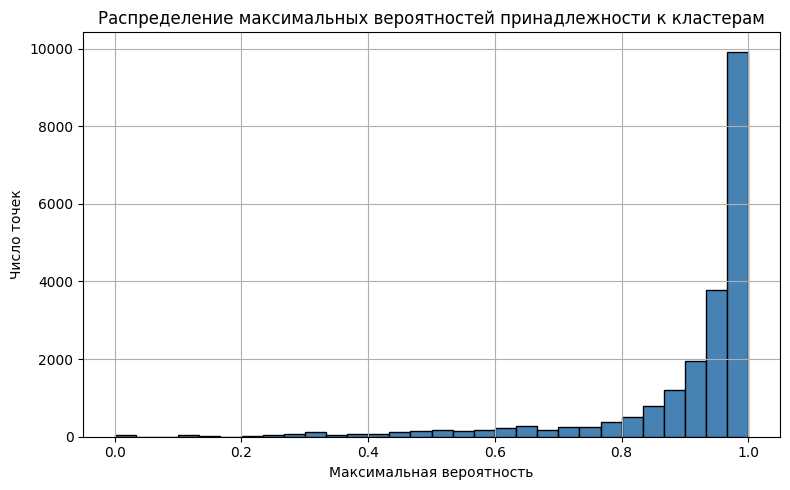

In [ ]:
probs.shape

if len(set(labels)) > 1:
    sil_score = silhouette_score(X_umap, labels)
else:
    sil_score = -1

max_probs = np.max(probs, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=30, color='steelblue', edgecolor='black')
plt.title("Распределение максимальных вероятностей принадлежности к кластерам")
plt.xlabel("Максимальная вероятность")
plt.ylabel("Число точек")
plt.grid(True)
plt.tight_layout()
plt.show()


In [93]:
probs.shape


(21000, 14)

In [95]:
sil_score

np.float32(0.92897815)

In [ ]:
# submission = pd.DataFrame({
#     'ID': np.arange(len(labels)),
#     'TARGET': labels
# })

# submission.to_csv('last_v_hdbscan_submission.csv', index=False)

0.12!!!🤣🎉

In [98]:
transformer = TfidfTransformer()
tfidf_matrix = transformer.fit_transform(train_cleaned)


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


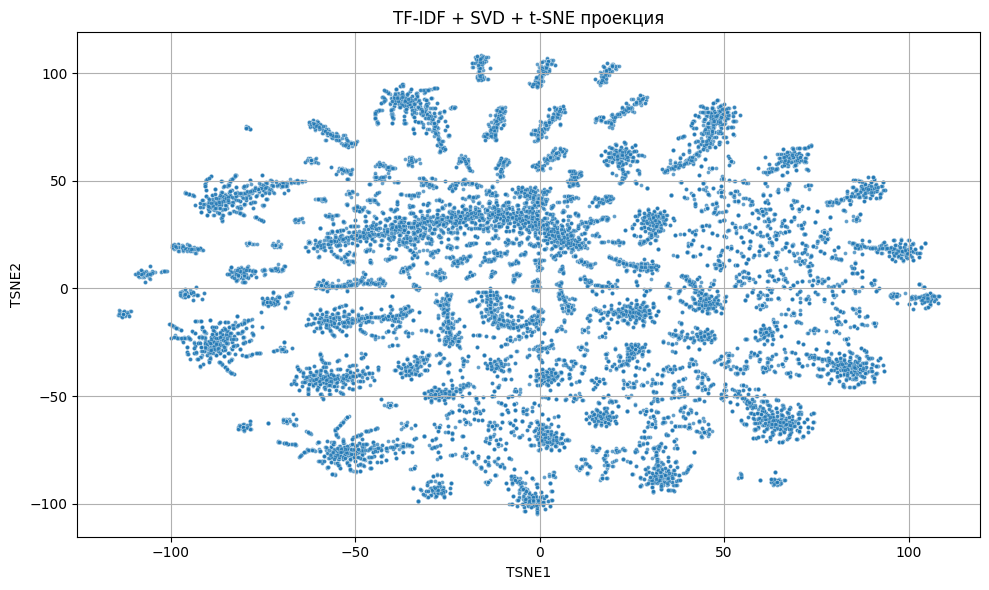

In [99]:
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tfidf_embedded = tsne.fit_transform(tfidf_reduced)

tfidf_df = pd.DataFrame(tfidf_embedded, columns=["TSNE1", "TSNE2"])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tfidf_df, x="TSNE1", y="TSNE2", s=8, alpha=0.7)
plt.title("TF-IDF + SVD + t-SNE проекция")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
transformer = TfidfTransformer()
tfidf_matrix = transformer.fit_transform(train)

In [105]:
svd = TruncatedSVD(n_components=150, random_state=42)
svd.fit(tfidf_matrix)

TruncatedSVD(n_components=150, random_state=42)

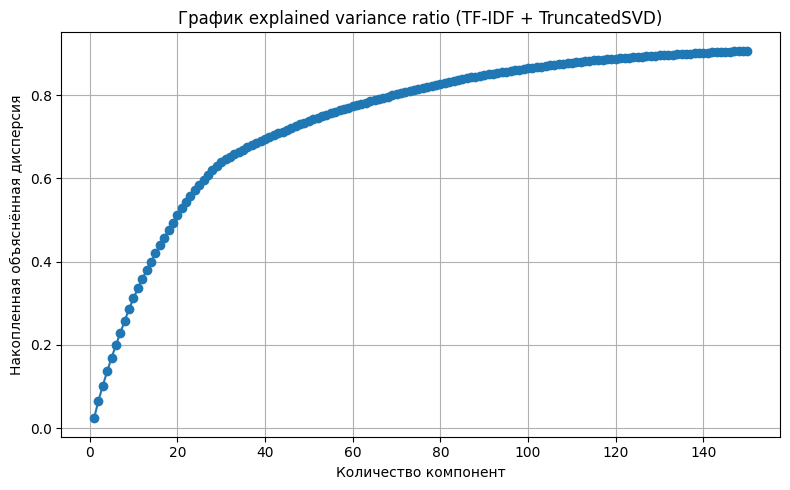

In [107]:
explained_variance = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 151), cumulative_variance, marker='o')
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная объяснённая дисперсия")
plt.title("График explained variance ratio (TF-IDF + TruncatedSVD)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [109]:
svd_60 = TruncatedSVD(n_components=60, random_state=42)
tfidf_svd_60 = svd_60.fit_transform(tfidf_matrix)

In [ ]:
tfidf_svd_60_df = pd.DataFrame(tfidf_svd_60, columns=[f"tfidf_svd_{i+1}" for i in range(60)])

full_augmented_features = pd.concat([
    full_scaled_features.reset_index(drop=True),
    tfidf_svd_60_df.reset_index(drop=True)], axis=1)

In [112]:
full_augmented_features.shape

(21000, 84)

In [113]:
full_augmented_features.head()

,density,density_rare,num_positive_rare,num_negative_rare,mean_sign_frequent,mean_value_frequent,sum_value_frequent,std_value_frequent,total_nonzero,total_positive,...,tfidf_svd_51,tfidf_svd_52,tfidf_svd_53,tfidf_svd_54,tfidf_svd_55,tfidf_svd_56,tfidf_svd_57,tfidf_svd_58,tfidf_svd_59,tfidf_svd_60
0,-0.962320,-1.074686,-0.917656,-1.029995,0.032764,0.076612,23.366588,1.212983,-0.949547,-0.824933,...,0.008477,-0.004491,0.010429,0.022926,0.034603,-0.060228,-0.003919,-0.052862,-0.033346,-0.043857
1,-0.609351,-0.873330,-0.566192,-1.029995,0.032289,0.073332,22.733058,1.506401,-0.593940,-0.476619,...,0.000424,-0.000554,-0.000781,-0.000509,-0.000085,0.000381,-0.000948,-0.000423,-0.000004,0.000664
2,0.390728,-0.470617,-0.566192,-0.274392,0.022317,-0.119357,-38.791147,1.361971,0.408805,-0.267884,...,0.000514,-0.000388,0.000537,-0.001199,-0.000708,-0.000649,-0.000054,-0.000696,-0.000693,0.000195
3,-0.609351,-1.074686,-0.917656,-1.029995,0.029915,-0.010575,-3.288678,1.325152,-0.593940,-0.137177,...,0.000394,-0.001366,0.000101,-0.000999,-0.000413,-0.001295,0.000757,-0.001332,0.000114,0.000132
4,0.861354,1.945657,2.245520,1.236815,0.031814,0.051955,16.677485,1.188278,0.880888,0.140977,...,0.000686,-0.002131,-0.000720,-0.002019,-0.001157,0.001743,0.000486,0.000333,0.000492,0.000039


In [ ]:
X_all = full_augmented_features.copy()
feature_names = X_all.columns.tolist()

initial_states = []
for feature in tqdm(feature_names, desc="Initial scores"):
    X = X_all[[feature]].values
    labels = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = np.sum(labels == -1) / len(labels)
    if n_clusters > 1:
        sil_score = silhouette_score(X, labels)
    else:
        sil_score = -1
    initial_states.append({
        "features": (feature,),
        "silhouette": sil_score,
        "n_clusters": n_clusters,
        "noise_pct": noise_pct,
        "n_features": 1
    })

beam = sorted(initial_states, key=lambda x: (-x['silhouette'], x['n_clusters']))[:beam_width]

all_states = beam.copy()

# ✨Beam Search✨
for depth in tqdm(range(2, max_features + 1), desc="Beam Search"):
    new_candidates = []
    for state in beam:
        used = set(state["features"])
        for feat in feature_names:
            if feat not in used:
                new_feats = tuple(sorted(list(used | {feat})))
                if any(s["features"] == new_feats for s in all_states):
                    continue
                X = X_all[list(new_feats)].values
                labels = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(X)
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                noise_pct = np.sum(labels == -1) / len(labels)
                if n_clusters > 1:
                    sil_score = silhouette_score(X, labels)
                else:
                    sil_score = -1
                candidate = {
                    "features": new_feats,
                    "silhouette": sil_score,
                    "n_clusters": n_clusters,
                    "noise_pct": noise_pct,
                    "n_features": len(new_feats)
                }
                new_candidates.append(candidate)
                all_states.append(candidate)
    beam = sorted(new_candidates, key=lambda x: (-x['silhouette'], x['n_clusters']))[:beam_width]

beam_feature_search = pd.DataFrame(all_states)


Beam Search: 100%|██████████| 9/9 [2:01:40<00:00, 811.20s/it]


In [ ]:
beam_feature_search.sort_values(by=["silhouette"])

filtered = beam_feature_search[(beam_feature_search["n_clusters"] <= 100) & 
(beam_feature_search["n_features"] >= 3)].sort_values(by=["silhouette", "n_clusters", "n_features"],
ascending=[False, True, True])

In [123]:
filtered.head(40)

,features,silhouette,n_clusters,noise_pct,n_features
333,"(num_negative_rare, Нечастые_251_2900_negative...",0.999004,13,0.001667,3
494,"(density_rare, Нечастые_251_2900_nonzero, Пост...",0.997702,22,0.000048,3
425,"(num_negative_rare, Нечастые_251_2900_negative...",0.940476,76,0.012524,3
667,"(num_negative_rare, Нечастые_251_2900_negative...",0.940476,76,0.012524,4
586,"(num_negative_rare, Нечастые_251_2900_pos_to_n...",0.937841,76,0.013381,3
344,"(Нечастые_251_2900_negative, Нечастые_251_2900...",0.934428,76,0.012667,3
748,"(density_rare, Нечастые_251_2900_nonzero, Неча...",0.933026,80,0.009952,4
827,"(num_negative_rare, Нечастые_251_2900_negative...",0.927290,81,0.014476,4
987,"(num_negative_rare, Нечастые_251_2900_negative...",0.927290,81,0.014476,5
907,"(num_negative_rare, Нечастые_251_2900_nonzero,...",0.924003,81,0.014810,4


In [127]:
explained = svd_60.explained_variance_ratio_
top_k = np.argsort(explained)[-3:][::-1]  # индексы трёх лучших компонент
top_features = [f'tfidf_svd_{i+1}' for i in top_k]
top_features

['tfidf_svd_2', 'tfidf_svd_3', 'tfidf_svd_4']

In [130]:
full_scaled_features['hdbscan_entropy'] = entropies
selected_features.append('hdbscan_entropy')


In [131]:
tfidf_sparse = transformer.fit_transform(train_cleaned) 
tfidf_density = np.array((tfidf_sparse != 0).sum(axis=1)).flatten() / tfidf_sparse.shape[1]
full_scaled_features['tfidf_density'] = tfidf_density
selected_features.append('tfidf_density')

In [138]:
results_df['entropy'].describe()

count    2.100000e+04
mean     1.058096e+00
std      1.501559e+00
min     -1.000000e-10
25%     -1.000000e-10
50%     -1.000000e-10
75%      2.480394e+00
max      4.821323e+00
Name: entropy, dtype: float64

In [139]:
full_scaled_features = pd.concat(
    [full_scaled_features.reset_index(drop=True), tfidf_svd_60_df[top_features].reset_index(drop=True)],
    axis=1
)

In [140]:
selected_features.append('tfidf_svd_2')
selected_features.append('tfidf_svd_3')
selected_features.append('tfidf_svd_4')

In [141]:
full_scaled_features.head(10)

,density,density_rare,num_positive_rare,num_negative_rare,mean_sign_frequent,mean_value_frequent,sum_value_frequent,std_value_frequent,total_nonzero,total_positive,...,Частые_2901_5000_pos_to_neg_ratio,Постоянные_gt5000_nonzero,Постоянные_gt5000_positive,Постоянные_gt5000_negative,Постоянные_gt5000_pos_to_neg_ratio,hdbscan_entropy,tfidf_density,tfidf_svd_2,tfidf_svd_3,tfidf_svd_4
0,-0.962320,-1.074686,-0.917656,-1.029995,0.032764,0.076612,23.366588,1.212983,-0.949547,-0.824933,...,-0.090452,-5.199338,-0.357496,0.357496,-0.357496,-1.000000e-10,0.222359,0.001772,0.003341,-0.000139
1,-0.609351,-0.873330,-0.566192,-1.029995,0.032289,0.073332,22.733058,1.506401,-0.593940,-0.476619,...,-0.218773,-5.199338,-0.015055,0.015055,-0.015055,1.595701e-01,0.224825,-0.420270,-0.085010,0.729513
2,0.390728,-0.470617,-0.566192,-0.274392,0.022317,-0.119357,-38.791147,1.361971,0.408805,-0.267884,...,-1.580377,-5.199338,1.025123,-1.025123,1.025123,-1.000000e-10,0.231813,-0.088412,0.538811,-0.008714
3,-0.609351,-1.074686,-0.917656,-1.029995,0.029915,-0.010575,-3.288678,1.325152,-0.593940,-0.137177,...,-0.532190,-5.199338,1.365257,-1.365257,1.365257,-1.000000e-10,0.224825,-0.135883,0.578567,-0.109039
4,0.861354,1.945657,2.245520,1.236815,0.031814,0.051955,16.677485,1.188278,0.880888,0.140977,...,-0.414267,-5.199338,-0.705530,0.705530,-0.705530,9.094470e-02,0.235101,0.046625,0.050995,-0.002098
5,0.214244,1.945657,2.596984,0.859013,0.042735,0.174051,53.955691,1.576040,0.238089,1.258508,...,1.044409,-5.199338,1.025123,-1.025123,1.025123,6.148533e-02,0.230580,0.226498,-0.085176,0.009759
6,0.331900,1.341588,1.542592,0.859013,0.046059,0.067131,21.146415,1.093707,0.352151,0.866189,...,1.372004,-5.199338,-0.532190,0.532190,-0.532190,4.001604e-01,0.231402,0.001857,0.004483,-0.000666
7,0.626041,-0.671974,-0.566192,-0.652194,0.044634,0.068124,22.480884,1.389863,0.648724,1.194628,...,0.952651,-5.199338,0.333524,-0.333524,0.333524,1.766589e-01,0.233457,0.689106,-0.237051,-0.004069
8,0.155416,-0.671974,-0.566192,-0.652194,0.044634,0.016074,5.175756,1.178431,0.175278,1.786156,...,1.079690,-5.199338,2.575483,-2.575483,2.575483,-1.000000e-10,0.230169,-0.400058,-0.231742,0.779357
9,-1.197632,-0.873330,-0.917656,-0.652194,0.036087,-0.037629,-11.288778,1.109693,-1.186981,-0.886449,...,0.405174,-5.199338,-0.705530,0.705530,-0.705530,3.535156e-01,0.220715,0.019893,0.000391,-0.001158


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Кластеров: 140 (из них шумом помечены: 1945)


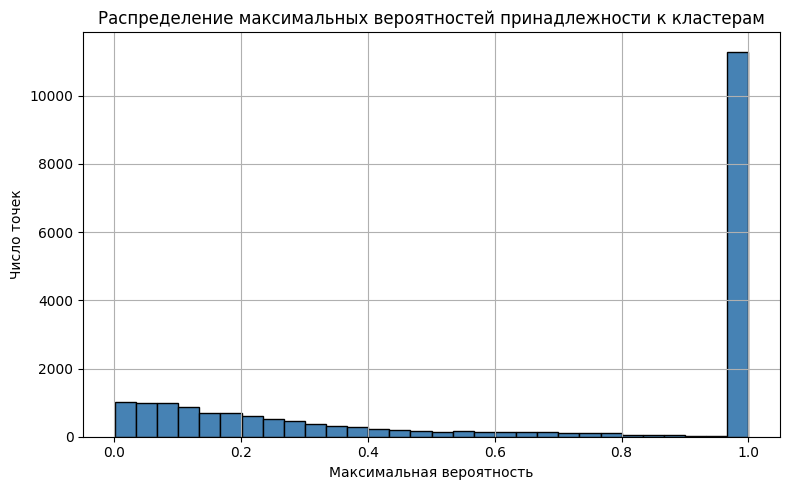

In [ ]:
X_best = full_scaled_features[selected_features].values

umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42, metric="euclidean")
X_umap = umap_model.fit_transform(X_best)

clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5, prediction_data=True)
labels = clusterer.fit_predict(X_umap)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct = np.sum(labels == -1) / len(labels)
sil_score = silhouette_score(X_umap, labels) if n_clusters > 1 else -1

probs = hdbscan.all_points_membership_vectors(clusterer)
entropies = -np.sum(probs * np.log(probs + 1e-10), axis=1)

results_df = pd.DataFrame({
    "label": labels,
    "entropy": entropies
})

n_clusters = len(np.unique(labels))
n_noise = np.sum(labels == -1)

print(f"Кластеров: {n_clusters} (из них шумом помечены: {n_noise})")

probs.shape

if len(set(labels)) > 1:
    sil_score = silhouette_score(X_umap, labels)
else:
    sil_score = -1

max_probs = np.max(probs, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=30, color='steelblue', edgecolor='black')
plt.title("Распределение максимальных вероятностей принадлежности к кластерам")
plt.xlabel("Максимальная вероятность")
plt.ylabel("Число точек")
plt.grid(True)
plt.tight_layout()
plt.show()


In [144]:
param_results = []

for n_neigh in [15, 30, 50]:
    for min_d in [0.0, 0.1, 0.3]:
        umap_model = umap.UMAP(n_neighbors=n_neigh, min_dist=min_d, random_state=42)
        X_umap = umap_model.fit_transform(X_best)

        for min_clust in [30, 50, 100]:
            for min_samp in [1, 5, 10]:
                clusterer = hdbscan.HDBSCAN(min_cluster_size=min_clust,
                                            min_samples=min_samp,
                                            prediction_data=True)
                labels = clusterer.fit_predict(X_umap)
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                noise = np.sum(labels == -1) / len(labels)
                sil = silhouette_score(X_umap, labels) if n_clusters > 1 else -1

                param_results.append({
                    "n_neighbors": n_neigh,
                    "min_dist": min_d,
                    "min_cluster_size": min_clust,
                    "min_samples": min_samp,
                    "n_clusters": n_clusters,
                    "noise_pct": noise,
                    "silhouette": sil
                })


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Do

In [147]:
results_param = pd.DataFrame(param_results)
sorted_param = results_param.sort_values(by="n_clusters")
sorted_param.reset_index(drop=True, inplace=True)

sorted_param.head(30)

,n_neighbors,min_dist,min_cluster_size,min_samples,n_clusters,noise_pct,silhouette
0,30,0.3,100,10,40,0.040762,0.177245
1,30,0.3,100,5,41,0.038476,0.177349
2,50,0.3,100,10,43,0.039000,0.209029
3,15,0.3,100,10,43,0.067667,0.137081
4,30,0.3,100,1,45,0.062857,0.200156
5,50,0.3,100,1,46,0.037905,0.177222
6,15,0.3,100,1,51,0.102810,0.130696
7,15,0.3,100,5,52,0.109524,0.155750
8,50,0.3,100,5,53,0.050714,0.165124
9,50,0.1,100,10,57,0.066905,0.296890


ПОСЛЕДНЯЯ ПОПЫТКА РАЗОБРАТЬСЯ В СТРУКТУРЕ ДАННЫХ

In [149]:
# признаки плотности
nonzero_count = (train != 0).sum(axis=1).A1
pos_ratio = (train > 0).sum(axis=1).A1 / (nonzero_count + 1e-6)
neg_ratio = (train < 0).sum(axis=1).A1 / (nonzero_count + 1e-6)

# плотные строки с "чистым знаком"
idx_core = np.where((nonzero_count > np.percentile(nonzero_count, 90)) & 
                    ((pos_ratio > 0.9) | (neg_ratio > 0.9)))[0]

In [150]:
idx_core

array([], dtype=int64)

In [ ]:

def compute_full_feature_df(train):
    nonzero_per_feature = (train != 0).sum(axis=0).A1 / train.shape[0]
    rare_idx = np.where((nonzero_per_feature > 0.0) & (nonzero_per_feature < 0.14))[0]
    frequent_idx = np.where((nonzero_per_feature >= 0.14) & (nonzero_per_feature < 0.9))[0]
    constant_idx = np.where(nonzero_per_feature >= 0.9)[0]

    # прототипы
    prototype_rare_positive = np.zeros(train.shape[1])
    prototype_rare_positive[rare_idx] = 1

    prototype_frequent_negative = np.zeros(train.shape[1])
    prototype_frequent_negative[frequent_idx] = -1

    prototype_constant_positive = np.zeros(train.shape[1])
    prototype_constant_positive[constant_idx] = 1

    sign_matrix = train.sign()

    sim1 = cosine_similarity(sign_matrix, prototype_rare_positive.reshape(1, -1)).ravel()
    sim2 = cosine_similarity(sign_matrix, prototype_frequent_negative.reshape(1, -1)).ravel()
    sim3 = cosine_similarity(sign_matrix, prototype_constant_positive.reshape(1, -1)).ravel()

    # базовые признаки
    features_df = pd.DataFrame({
        'sim_rare_pos': sim1,
        'sim_freq_neg': sim2,
        'sim_const_pos': sim3,
        'density': (train != 0).sum(axis=1).A1 / train.shape[1],
        'pos_ratio': (train > 0).sum(axis=1).A1 / ((train != 0).sum(axis=1).A1 + 1e-6),
        'neg_ratio': (train < 0).sum(axis=1).A1 / ((train != 0).sum(axis=1).A1 + 1e-6),
    })

    return features_df, rare_idx, frequent_idx


In [180]:
features_df, rare_idx, frequent_idx = compute_full_feature_df(train)

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


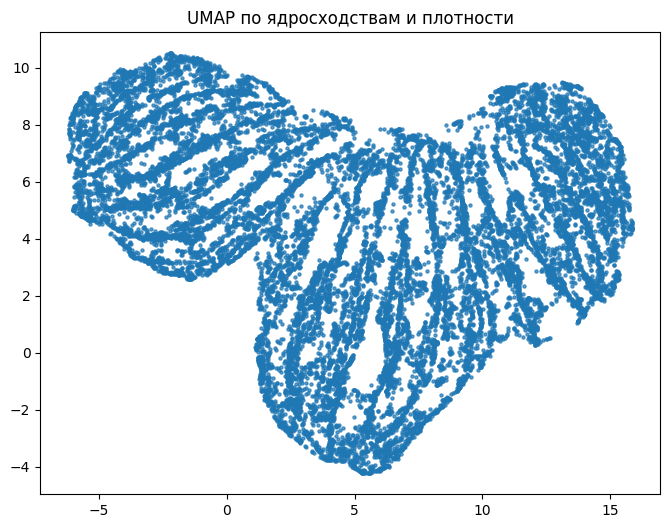

In [159]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding = reducer.fit_transform(features_df)

plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.7)
plt.title('UMAP по ядросходствам и плотности')
plt.show()

In [ ]:
def param_search_umap_hdbscan(features_df):
    param_results = []

    n_neighbors_list = [15, 30, 50]
    min_dist_list = [0.0, 0.1, 0.3]
    min_cluster_size_list = [30, 50, 100]
    min_samples_list = [1, 5, 10]

    for n_neigh in n_neighbors_list:
        for min_d in min_dist_list:
            umap_model = umap.UMAP(n_neighbors=n_neigh, min_dist=min_d, random_state=42)
            X_umap = umap_model.fit_transform(features_df)

            for min_clust in min_cluster_size_list:
                for min_samp in min_samples_list:
                    # HDBSCAN на UMAP
                    clusterer_umap = hdbscan.HDBSCAN(min_cluster_size=min_clust,
                                                     min_samples=min_samp,
                                                     prediction_data=True)
                    labels_umap = clusterer_umap.fit_predict(X_umap)
                    n_clusters_umap = len(set(labels_umap)) - (1 if -1 in labels_umap else 0)
                    noise_umap = np.sum(labels_umap == -1) / len(labels_umap)
                    sil_umap = silhouette_score(X_umap, labels_umap) if n_clusters_umap > 1 else -1

                    param_results.append({
                        "mode": "UMAP+HDBSCAN",
                        "n_neighbors": n_neigh,
                        "min_dist": min_d,
                        "min_cluster_size": min_clust,
                        "min_samples": min_samp,
                        "n_clusters": n_clusters_umap,
                        "noise_pct": noise_umap,
                        "silhouette": sil_umap
                    })

                    # HDBSCAN без UMAP (на features_df)
                    clusterer_plain = hdbscan.HDBSCAN(min_cluster_size=min_clust,
                                                      min_samples=min_samp,
                                                      prediction_data=True)
                    labels_plain = clusterer_plain.fit_predict(features_df)
                    n_clusters_plain = len(set(labels_plain)) - (1 if -1 in labels_plain else 0)
                    noise_plain = np.sum(labels_plain == -1) / len(labels_plain)
                    sil_plain = silhouette_score(features_df, labels_plain) if n_clusters_plain > 1 else -1

                    param_results.append({
                        "mode": "HDBSCAN only",
                        "n_neighbors": None,
                        "min_dist": None,
                        "min_cluster_size": min_clust,
                        "min_samples": min_samp,
                        "n_clusters": n_clusters_plain,
                        "noise_pct": noise_plain,
                        "silhouette": sil_plain
                    })

    return pd.DataFrame(param_results)

In [162]:
results_df = param_search_umap_hdbscan(features_df)

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Do

In [174]:
results_df = results_df.sort_values("n_clusters", ascending=True)
results_df

,mode,n_neighbors,min_dist,min_cluster_size,min_samples,n_clusters,noise_pct,silhouette
53,HDBSCAN only,NaN,NaN,100,10,18,0.559429,-0.283929
71,HDBSCAN only,NaN,NaN,100,10,18,0.559429,-0.283929
89,HDBSCAN only,NaN,NaN,100,10,18,0.559429,-0.283929
143,HDBSCAN only,NaN,NaN,100,10,18,0.559429,-0.283929
17,HDBSCAN only,NaN,NaN,100,10,18,0.559429,-0.283929
...,...,...,...,...,...,...,...,...
72,UMAP+HDBSCAN,30.0,0.1,30,1,234,0.211333,0.104654
18,UMAP+HDBSCAN,15.0,0.1,30,1,238,0.180762,0.120067
2,UMAP+HDBSCAN,15.0,0.0,30,5,243,0.196286,0.180858
54,UMAP+HDBSCAN,30.0,0.0,30,1,243,0.190714,0.165532


In [ ]:
def build_extended_features(train, features_df, rare_idx, frequent_idx):
    num_positive_rare = (train[:, rare_idx] > 0).sum(axis=1).A1
    num_negative_rare = (train[:, rare_idx] < 0).sum(axis=1).A1

    mean_value_frequent = np.array(train[:, frequent_idx].mean(axis=1)).ravel()
    std_value_frequent = np.sqrt(train[:, frequent_idx].power(2).mean(axis=1).A1 - mean_value_frequent**2)

    sign_frequent = train[:, frequent_idx].sign()
    mean_sign_frequent = sign_frequent.mean(axis=1).A1

    features_df_extended = features_df.copy()
    features_df_extended["num_positive_rare"] = num_positive_rare
    features_df_extended["num_negative_rare"] = num_negative_rare
    features_df_extended["mean_value_frequent"] = mean_value_frequent
    features_df_extended["std_value_frequent"] = std_value_frequent
    features_df_extended["mean_sign_frequent"] = mean_sign_frequent

    return features_df_extended

In [188]:
features_df_extended = build_extended_features(train, features_df, rare_idx, frequent_idx)

In [189]:
features_df_extended.describe().T

,count,mean,std,min,25%,50%,75%,max
sim_rare_pos,21000.0,-0.000578,0.010547,-0.052728,-0.004459,0.000000,0.004386,0.059000
sim_freq_neg,21000.0,-0.067253,0.016201,-0.155840,-0.078117,-0.067119,-0.056514,-0.005673
sim_const_pos,21000.0,-0.065450,0.032057,-0.224959,-0.087479,-0.065842,-0.044012,0.066737
density,21000.0,0.182800,0.005575,0.162676,0.179075,0.182683,0.186619,0.205313
pos_ratio,21000.0,0.543881,0.018978,0.476371,0.531197,0.543828,0.556738,0.629693
neg_ratio,21000.0,0.456119,0.018978,0.370307,0.443262,0.456172,0.468803,0.523629
num_positive_rare,21000.0,2.810571,2.832721,0.000000,1.000000,2.000000,4.000000,18.000000
num_negative_rare,21000.0,2.942381,2.756290,0.000000,1.000000,2.000000,5.000000,18.000000
mean_value_frequent,21000.0,46.642828,52.248856,-0.257857,0.116088,47.445603,87.520753,332.833817
std_value_frequent,21000.0,1563.583767,1434.781074,1.194986,8.824596,2180.106682,2796.687626,5759.780952


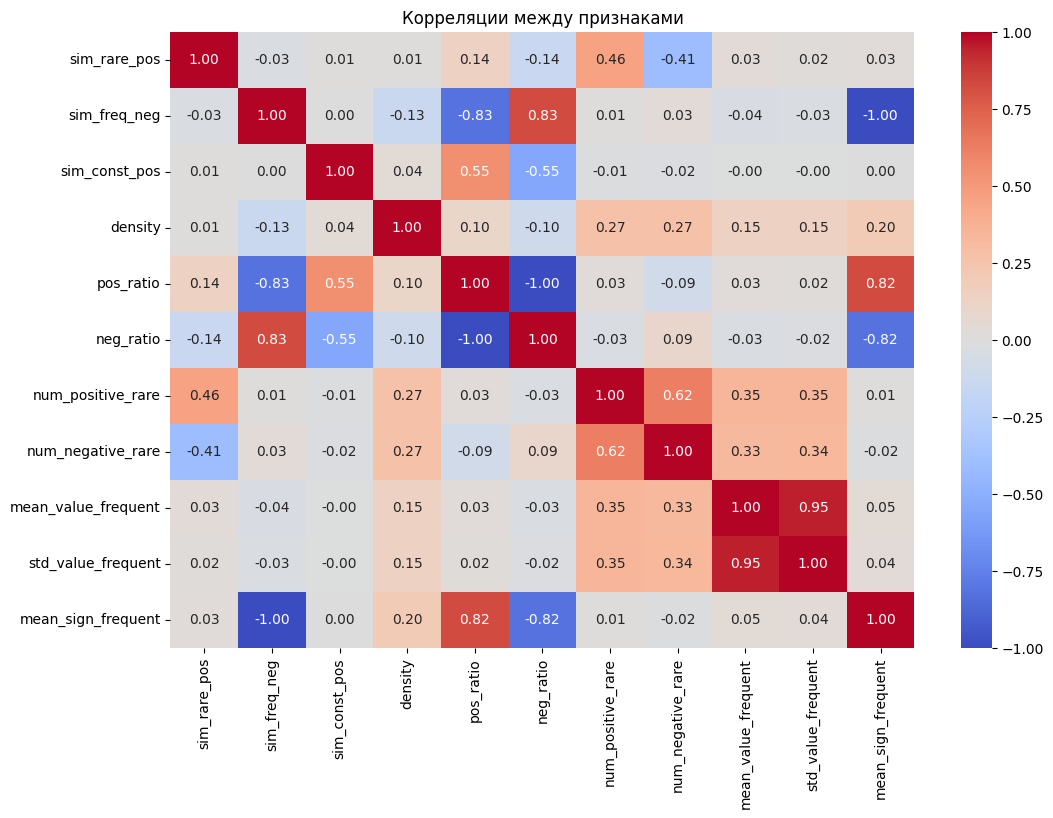

In [190]:
correlation_matrix = features_df_extended.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляции между признаками")
plt.show()

In [191]:
high_corr_pairs = []
threshold = 0.8
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > threshold:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr))

high_corr_pairs

[('sim_freq_neg', 'pos_ratio', np.float64(-0.826700109825458)),
 ('sim_freq_neg', 'neg_ratio', np.float64(0.8267001096796234)),
 ('sim_freq_neg', 'mean_sign_frequent', np.float64(-0.9979464846284143)),
 ('pos_ratio', 'neg_ratio', np.float64(-0.9999999999999963)),
 ('pos_ratio', 'mean_sign_frequent', np.float64(0.8241725562638258)),
 ('neg_ratio', 'mean_sign_frequent', np.float64(-0.8241725559404157)),
 ('mean_value_frequent', 'std_value_frequent', np.float64(0.948179783626739))]

In [192]:
features_df_extended.drop(columns=["sim_freq_neg", "std_value_frequent", 'pos_ratio', 'neg_ratio'], inplace=True)

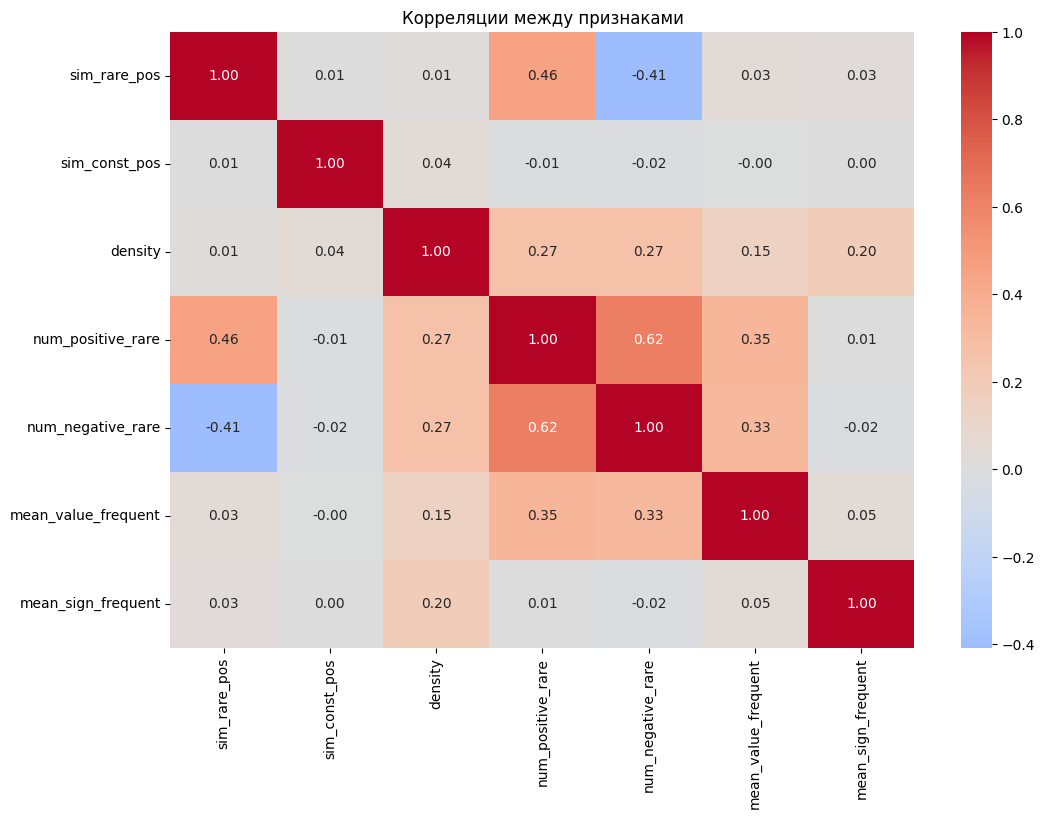

[]

In [193]:
correlation_matrix = features_df_extended.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляции между признаками")
plt.show()

high_corr_pairs = []
threshold = 0.8
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > threshold:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr))

high_corr_pairs

In [194]:
features_df_extended.describe().T

,count,mean,std,min,25%,50%,75%,max
sim_rare_pos,21000.0,-0.000578,0.010547,-0.052728,-0.004459,0.000000,0.004386,0.059000
sim_const_pos,21000.0,-0.065450,0.032057,-0.224959,-0.087479,-0.065842,-0.044012,0.066737
density,21000.0,0.182800,0.005575,0.162676,0.179075,0.182683,0.186619,0.205313
num_positive_rare,21000.0,2.810571,2.832721,0.000000,1.000000,2.000000,4.000000,18.000000
num_negative_rare,21000.0,2.942381,2.756290,0.000000,1.000000,2.000000,5.000000,18.000000
mean_value_frequent,21000.0,46.642828,52.248856,-0.257857,0.116088,47.445603,87.520753,332.833817
mean_sign_frequent,21000.0,0.034636,0.008431,0.002853,0.029006,0.034712,0.040418,0.082263


In [196]:
selected_features = [
    "sim_rare_pos", "sim_const_pos", "density",
    "num_positive_rare", "num_negative_rare",
    "mean_value_frequent", "mean_sign_frequent"
]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df_extended[selected_features])

In [198]:
features_scaled.shape, features_scaled[:3]


((21000, 7),
 array([[ 0.05477927, -0.40278583, -0.96231954, -0.99220443, -1.06754026,
         -0.81991809, -0.21650955],
        [ 0.47292462, -0.04205086, -0.60935055, -0.63917856, -1.06754026,
          0.25169347, -0.27291113],
        [ 0.05477927,  1.01564529,  0.39072827, -0.28615268, -0.34191004,
          0.01399213, -1.51374589]]))

In [200]:
results_df = param_search_umap_hdbscan(features_scaled)

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Do

In [207]:
results_df_fltrd = results_df[results_df['silhouette'] > 0].sort_values(by="noise_pct", ascending=True)
results_df_fltrd

,mode,n_neighbors,min_dist,min_cluster_size,min_samples,n_clusters,noise_pct,silhouette
120,UMAP+HDBSCAN,50.0,0.0,100,1,2,0.009333,0.255899
116,UMAP+HDBSCAN,50.0,0.0,50,5,2,0.027095,0.299528
122,UMAP+HDBSCAN,50.0,0.0,100,5,2,0.027095,0.299528
48,UMAP+HDBSCAN,15.0,0.3,100,1,4,0.032810,0.012049
138,UMAP+HDBSCAN,50.0,0.1,100,1,3,0.039952,0.191364
124,UMAP+HDBSCAN,50.0,0.0,100,10,2,0.053286,0.301734
102,UMAP+HDBSCAN,30.0,0.3,100,1,3,0.066238,0.162684
118,UMAP+HDBSCAN,50.0,0.0,50,10,3,0.068381,0.168660
114,UMAP+HDBSCAN,50.0,0.0,50,1,39,0.107952,0.151330
106,UMAP+HDBSCAN,30.0,0.3,100,10,2,0.112000,0.309384


In [ ]:
def beam_search_hdbscan(X_all, beam_width=4, max_features=10, min_cluster_size=50, min_samples=5):
    feature_names = X_all.columns.tolist()

    # начальное состояние: одиночные признаки
    initial_states = []
    for feature in feature_names:
        X = X_all[[feature]].values
        labels = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples).fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = np.sum(labels == -1) / len(labels)
        sil_score = silhouette_score(X, labels) if n_clusters > 1 else -1

        initial_states.append({
            "features": (feature,),
            "silhouette": sil_score,
            "n_clusters": n_clusters,
            "noise_pct": noise_pct
        })

    # стартовый beam
    beam = sorted(initial_states, key=lambda x: (-x['silhouette'], x['n_clusters']))[:beam_width]
    all_states = beam.copy()

    # поиск
    for depth in tqdm(range(2, max_features + 1), desc="Beam Search"):
        new_candidates = []
        for state in beam:
            used = set(state["features"])
            for feat in feature_names:
                if feat not in used:
                    new_feats = tuple(sorted(used | {feat}))
                    if any(s["features"] == new_feats for s in all_states):
                        continue
                    X = X_all[list(new_feats)].values
                    labels = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples).fit_predict(X)
                    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                    noise_pct = np.sum(labels == -1) / len(labels)
                    sil_score = silhouette_score(X, labels) if n_clusters > 1 else -1

                    candidate = {
                        "features": new_feats,
                        "silhouette": sil_score,
                        "n_clusters": n_clusters,
                        "noise_pct": noise_pct
                    }
                    new_candidates.append(candidate)
                    all_states.append(candidate)

        beam = sorted(new_candidates, key=lambda x: (x['silhouette'], -x['noise_pct'], x['n_clusters']), reverse=True)[:beam_width]

    return pd.DataFrame(all_states)


In [210]:
selected_features = [
    "sim_rare_pos", "sim_const_pos", "density",
    "num_positive_rare", "num_negative_rare",
    "mean_value_frequent", "mean_sign_frequent"
]

X_new = pd.DataFrame(features_scaled, columns=selected_features)

beam_feature_search = beam_search_hdbscan(X_new)

Beam Search: 100%|██████████| 9/9 [01:55<00:00, 12.84s/it]


In [222]:
beam_feature_search = beam_feature_search.sort_values(by='silhouette', ascending=False)
beam_feature_search

,features,silhouette,n_clusters,noise_pct
0,"(num_negative_rare,)",0.998311,14,0.000048
1,"(num_positive_rare,)",0.996808,14,0.000333
2,"(density,)",0.974894,78,0.006857
7,"(num_negative_rare, num_positive_rare)",0.898994,84,0.022048
22,"(num_negative_rare, num_positive_rare, sim_rar...",0.753164,95,0.043286
...,...,...,...,...
60,"(density, mean_value_frequent, num_negative_ra...",-0.222698,41,0.558429
16,"(density, sim_const_pos)",-0.241021,40,0.035095
61,"(density, mean_sign_frequent, mean_value_frequ...",-0.246658,17,0.790381
35,"(density, num_negative_rare, sim_const_pos)",-0.258327,76,0.198333


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


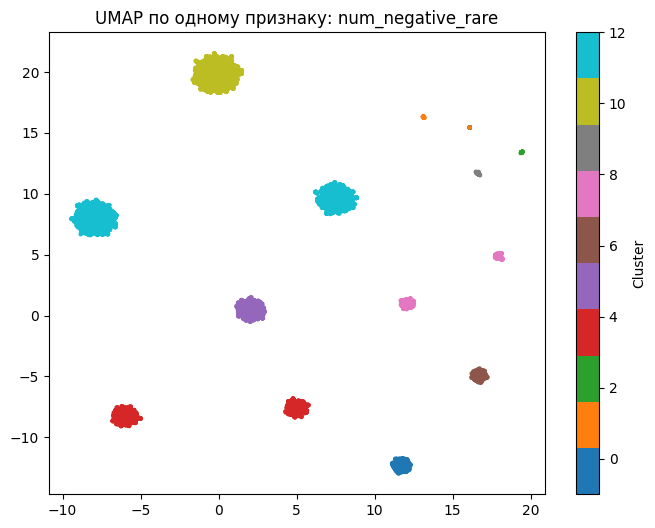

In [223]:
X_single = X_all[["num_negative_rare"]].values

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap_single = reducer.fit_transform(X_single)

labels_single = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(X_single)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap_single[:, 0], X_umap_single[:, 1], c=labels_single, cmap='tab10', s=5)
plt.title("UMAP по одному признаку: num_negative_rare")
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
# submission = pd.DataFrame({
#     'ID': np.arange(len(labels_single)),
#     'TARGET': labels_single
# })

# submission.to_csv('haha_submission.csv', index=False)

за день до конца контеста, запустив по приколу кластеризацию на одном признаке, узнать, что она побила все твои сложный пайплайны с лучевым поиском в два часа и прочим.... сильно)))))

придётся прогнать все остальные признаки по одному тоже🫠

восстановим все признаки, которые получали, в исходном виде...

In [232]:
initial_feature_df = build_feature_table(
    train_cleaned=train_cleaned,
    train_cleaned_log=train_cleaned_log,
    selected_indices_rare=selected_indices_rare,
    selected_indices_frequent=selected_indices_frequent,
    louvain_labels_signs=louvain_labels_signs
)
initial_feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
louvain_signs_k20,21000.0,6.360381,6.053906,0.000000,0.000000,5.000000,12.000000,19.000000
density,21000.0,557.358143,16.999065,496.000000,546.000000,557.000000,569.000000,626.000000
density_rare,21000.0,5.337238,4.966441,0.000000,1.000000,4.000000,9.000000,27.000000
num_positive_rare,21000.0,2.610952,2.845310,0.000000,0.000000,2.000000,4.000000,17.000000
num_negative_rare,21000.0,2.726286,2.646954,0.000000,1.000000,2.000000,4.000000,17.000000
mean_sign_frequent,21000.0,0.034578,0.008427,0.002374,0.028965,0.034663,0.040361,0.082146
mean_value_frequent,21000.0,0.017179,0.077828,-0.279725,-0.036101,0.014777,0.067660,0.384120
sum_value_frequent,21000.0,5.425267,24.561772,-84.756675,-11.342443,4.667876,21.379835,129.448291
std_value_frequent,21000.0,1.321995,0.186503,0.840894,1.171894,1.300572,1.445636,2.112335


In [233]:
features_df_extended.describe().T

,count,mean,std,min,25%,50%,75%,max
sim_rare_pos,21000.0,-0.000578,0.010547,-0.052728,-0.004459,0.000000,0.004386,0.059000
sim_const_pos,21000.0,-0.065450,0.032057,-0.224959,-0.087479,-0.065842,-0.044012,0.066737
density,21000.0,0.182800,0.005575,0.162676,0.179075,0.182683,0.186619,0.205313
num_positive_rare,21000.0,2.810571,2.832721,0.000000,1.000000,2.000000,4.000000,18.000000
num_negative_rare,21000.0,2.942381,2.756290,0.000000,1.000000,2.000000,5.000000,18.000000
mean_value_frequent,21000.0,46.642828,52.248856,-0.257857,0.116088,47.445603,87.520753,332.833817
mean_sign_frequent,21000.0,0.034636,0.008431,0.002853,0.029006,0.034712,0.040418,0.082263


In [234]:
aggregated_features.describe().T

,count,mean,std,min,25%,50%,75%,max
total_nonzero,21000.0,557.358143,16.999065,496.000000,546.000000,557.000000,569.000000,626.000000
total_positive,21000.0,303.169095,14.736705,249.000000,293.000000,303.000000,313.000000,369.000000
total_negative,21000.0,254.189048,12.459918,206.000000,246.000000,254.000000,263.000000,299.000000
pos_to_neg_ratio,21000.0,1.196225,0.091887,0.909747,1.133094,1.192157,1.256000,1.700461
Нечастые_251_2900_nonzero,21000.0,5.337238,4.966441,0.000000,1.000000,4.000000,9.000000,27.000000
Нечастые_251_2900_positive,21000.0,2.610952,2.845310,0.000000,0.000000,2.000000,4.000000,17.000000
Нечастые_251_2900_negative,21000.0,2.726286,2.646954,0.000000,1.000000,2.000000,4.000000,17.000000
Нечастые_251_2900_pos_to_neg_ratio,21000.0,0.784069,0.996225,0.000000,0.000000,0.500000,1.000000,13.000000
Частые_2901_5000_nonzero,21000.0,316.020905,16.231573,255.000000,305.000000,316.000000,327.000000,387.000000
Частые_2901_5000_positive,21000.0,194.421571,13.205250,148.000000,185.000000,194.000000,203.000000,260.000000


In [235]:
# расчёт метрик кластеризации по каждому признаку
def run_featurewise_clustering(df, source_name):
    results = []
    for col in tqdm(df.columns, desc=f"Clustering: {source_name}"):
        x = df[col].values.reshape(-1, 1)
        if np.std(x) == 0:  # исключаем константные признаки
            continue
        try:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
            labels = clusterer.fit_predict(x)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_pct = np.sum(labels == -1) / len(labels)
            silhouette = silhouette_score(x, labels) if n_clusters > 1 else -1
            results.append({
                "feature": col,
                "source": source_name,
                "n_clusters": n_clusters,
                "noise_pct": noise_pct,
                "silhouette": silhouette
            })
        except:
            continue
    return pd.DataFrame(results)


In [236]:
df1 = run_featurewise_clustering(initial_feature_df, "initial_feature_df")
df2 = run_featurewise_clustering(aggregated_features, "aggregated_features")
df3 = run_featurewise_clustering(features_df_extended[["sim_rare_pos", "sim_const_pos"]], "features_df_extended")


Clustering: features_df_extended: 100%|██████████| 2/2 [00:06<00:00,  3.22s/it]


In [237]:
df1 = df1.sort_values(by="silhouette", ascending=False)
df2 = df2.sort_values(by="silhouette", ascending=False)
df3 = df3.sort_values(by="silhouette", ascending=False)

df1

,feature,source,n_clusters,noise_pct,silhouette
0,louvain_signs_k20,initial_feature_df,20,0.000000,1.000000
4,num_negative_rare,initial_feature_df,13,0.001667,0.998891
3,num_positive_rare,initial_feature_df,13,0.004429,0.997210
2,density_rare,initial_feature_df,22,0.000048,0.996785
1,density,initial_feature_df,77,0.005190,0.974521
5,mean_sign_frequent,initial_feature_df,80,0.006619,0.972175
7,sum_value_frequent,initial_feature_df,162,0.065571,0.381664
8,std_value_frequent,initial_feature_df,184,0.075381,0.377816
6,mean_value_frequent,initial_feature_df,144,0.047095,0.376696


In [238]:
df2

,feature,source,n_clusters,noise_pct,silhouette
6,Нечастые_251_2900_negative,aggregated_features,13,0.001667,0.998891
5,Нечастые_251_2900_positive,aggregated_features,13,0.004429,0.997210
4,Нечастые_251_2900_nonzero,aggregated_features,22,0.000048,0.996785
13,Постоянные_gt5000_negative,aggregated_features,32,0.001571,0.993162
12,Постоянные_gt5000_positive,aggregated_features,31,0.000571,0.991009
14,Постоянные_gt5000_pos_to_neg_ratio,aggregated_features,31,0.004667,0.990358
10,Частые_2901_5000_negative,aggregated_features,54,0.002857,0.985905
2,total_negative,aggregated_features,60,0.000476,0.981183
8,Частые_2901_5000_nonzero,aggregated_features,76,0.001571,0.979500
9,Частые_2901_5000_positive,aggregated_features,62,0.000524,0.979409


In [239]:
df3

,feature,source,n_clusters,noise_pct,silhouette
0,sim_rare_pos,features_df_extended,127,0.147333,0.524716
1,sim_const_pos,features_df_extended,21,0.010190,0.412893


In [242]:
top_cols = pd.concat([
    initial_feature_df[["num_negative_rare", "num_positive_rare", "density_rare"]],
    aggregated_features[[
        "Нечастые_251_2900_negative",
        "Нечастые_251_2900_positive",
        "Нечастые_251_2900_nonzero",
        "Постоянные_gt5000_negative",
        "Постоянные_gt5000_positive"
    ]]], axis=1)


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


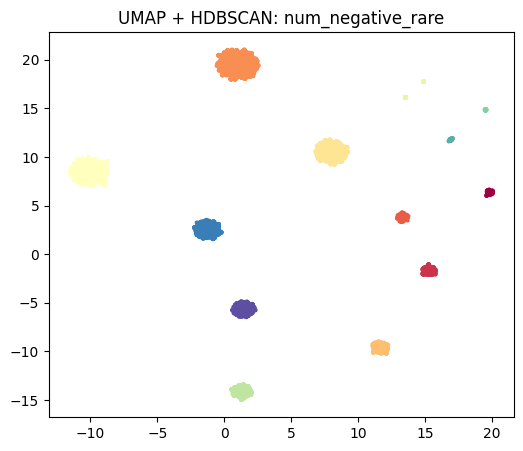

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


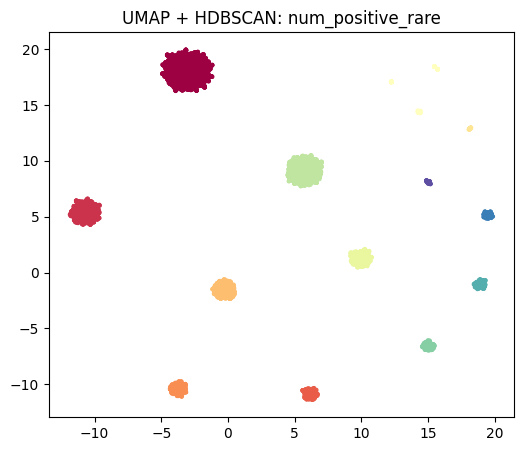

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


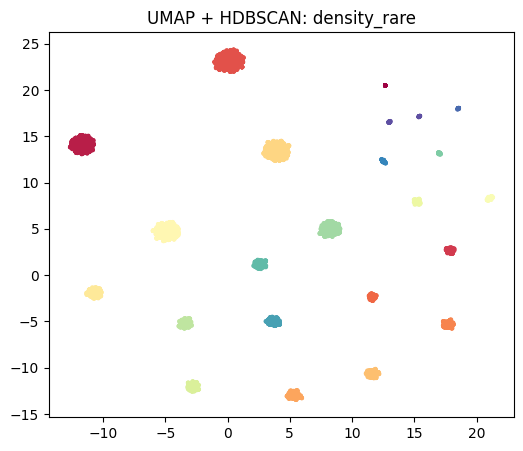

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


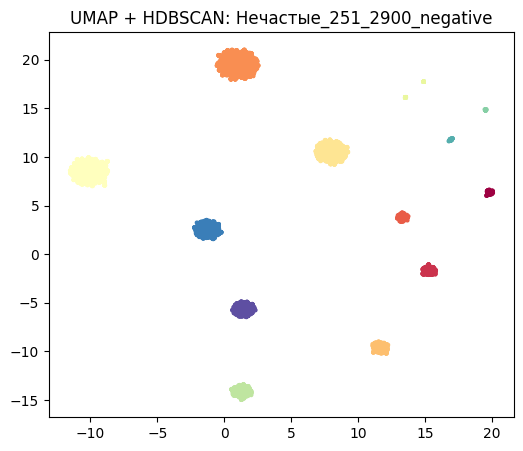

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


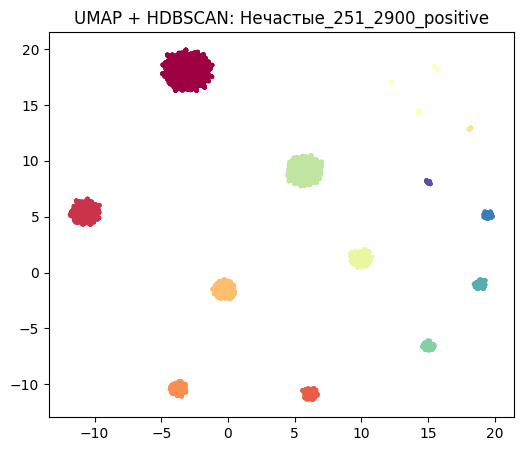

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


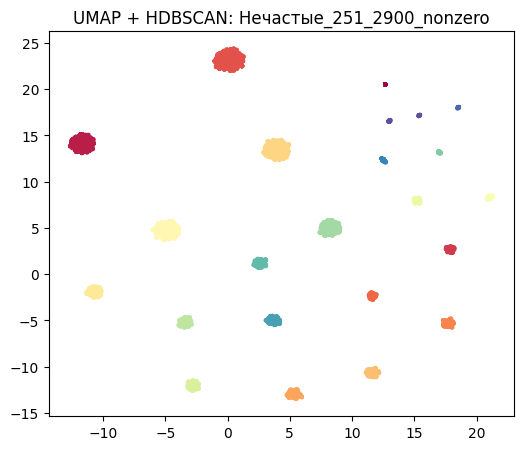

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


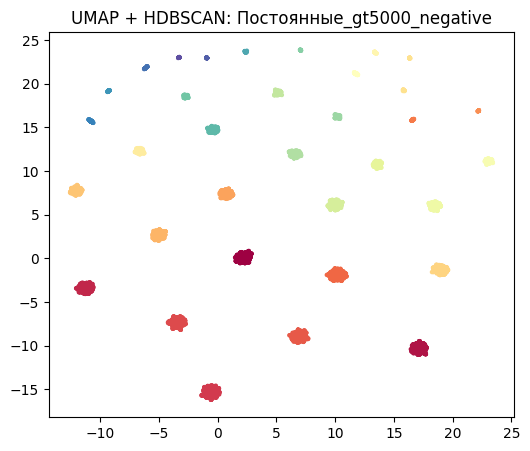

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


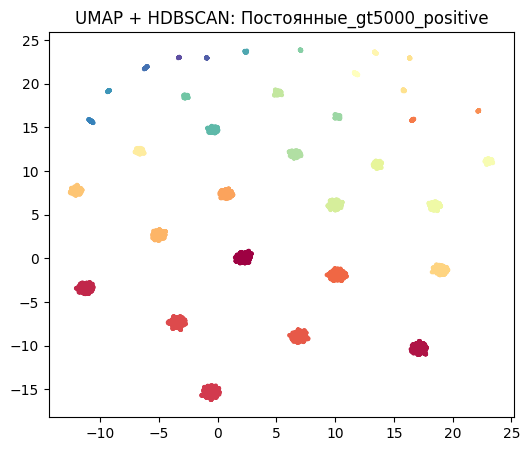

In [244]:
for col in top_cols.columns:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(top_cols[[col]])
    
    clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
    labels = clusterer.fit_predict(embedding)

    plt.figure(figsize=(6, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=5)
    plt.title(f"UMAP + HDBSCAN: {col}")
    plt.show()

In [248]:
beam_cols = [
    "num_negative_rare",
    "num_positive_rare",
    "density_rare",
    "Постоянные_gt5000_positive"
]

In [250]:
beam_df = top_cols[beam_cols].copy()

beam_df_scaled = pd.DataFrame(StandardScaler().fit_transform(beam_df), columns=beam_df.columns)


In [251]:
beam_result = beam_search_hdbscan(beam_df_scaled)
beam_result = beam_result.sort_values("silhouette", ascending=False)
beam_result

Beam Search: 100%|██████████| 9/9 [00:26<00:00,  2.98s/it]


,features,silhouette,n_clusters,noise_pct
0,"(num_negative_rare,)",0.998159,13,0.000333
1,"(num_positive_rare,)",0.997210,13,0.004429
2,"(density_rare,)",0.997066,22,0.000143
3,"(Постоянные_gt5000_positive,)",0.993094,32,0.002095
5,"(density_rare, num_negative_rare)",0.912693,81,0.023857
7,"(density_rare, num_positive_rare)",0.910195,81,0.027048
4,"(num_negative_rare, num_positive_rare)",0.902663,80,0.022619
10,"(density_rare, num_negative_rare, num_positive...",0.897995,79,0.025476
8,"(num_positive_rare, Постоянные_gt5000_positive)",0.787147,149,0.030476
6,"(num_negative_rare, Постоянные_gt5000_positive)",0.782666,148,0.038619


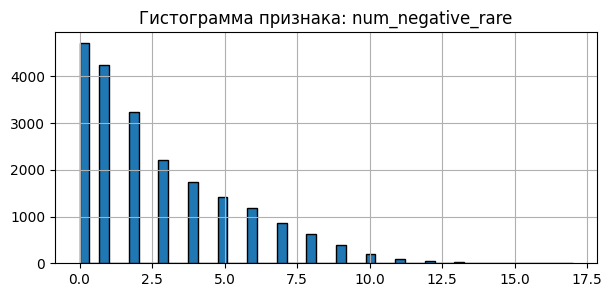

Кол-во уникальных значений: 18
Топ-10 значений:
num_negative_rare
0    4710
1    4237
2    3239
3    2211
4    1741
5    1412
6    1173
7     871
8     632
9     386
Name: count, dtype: int64
--------------------------------------------------


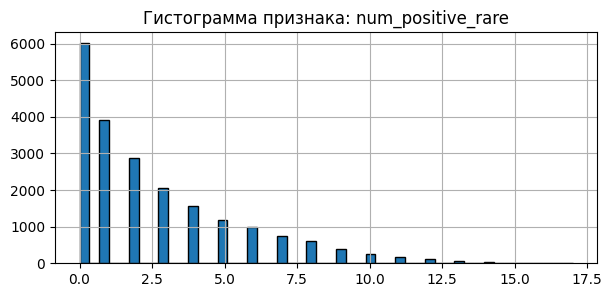

Кол-во уникальных значений: 18
Топ-10 значений:
num_positive_rare
0    6008
1    3912
2    2880
3    2052
4    1577
5    1192
6     992
7     747
8     601
9     400
Name: count, dtype: int64
--------------------------------------------------


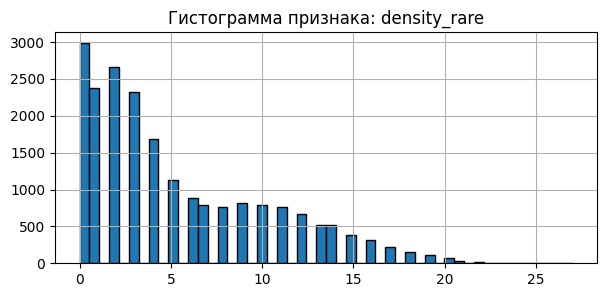

Кол-во уникальных значений: 28
Топ-10 значений:
density_rare
0     2983
2     2656
1     2383
3     2324
4     1682
5     1131
6      885
9      815
7      796
10     796
Name: count, dtype: int64
--------------------------------------------------


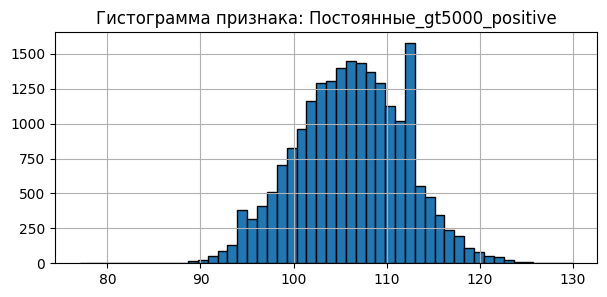

Кол-во уникальных значений: 48
Топ-10 значений:
Постоянные_gt5000_positive
106    1447
107    1437
105    1399
108    1372
104    1302
109    1292
103    1289
102    1161
110    1129
111    1018
Name: count, dtype: int64
--------------------------------------------------


In [254]:
for col in beam_cols:
    plt.figure(figsize=(7, 3))
    plt.hist(top_cols[col], bins=50, edgecolor="black")
    plt.title(f"Гистограмма признака: {col}")
    plt.grid(True)
    plt.show()

    print(f"Кол-во уникальных значений: {top_cols[col].nunique()}")
    print(f"Топ-10 значений:\n{top_cols[col].value_counts().head(10)}")
    print("-" * 50)


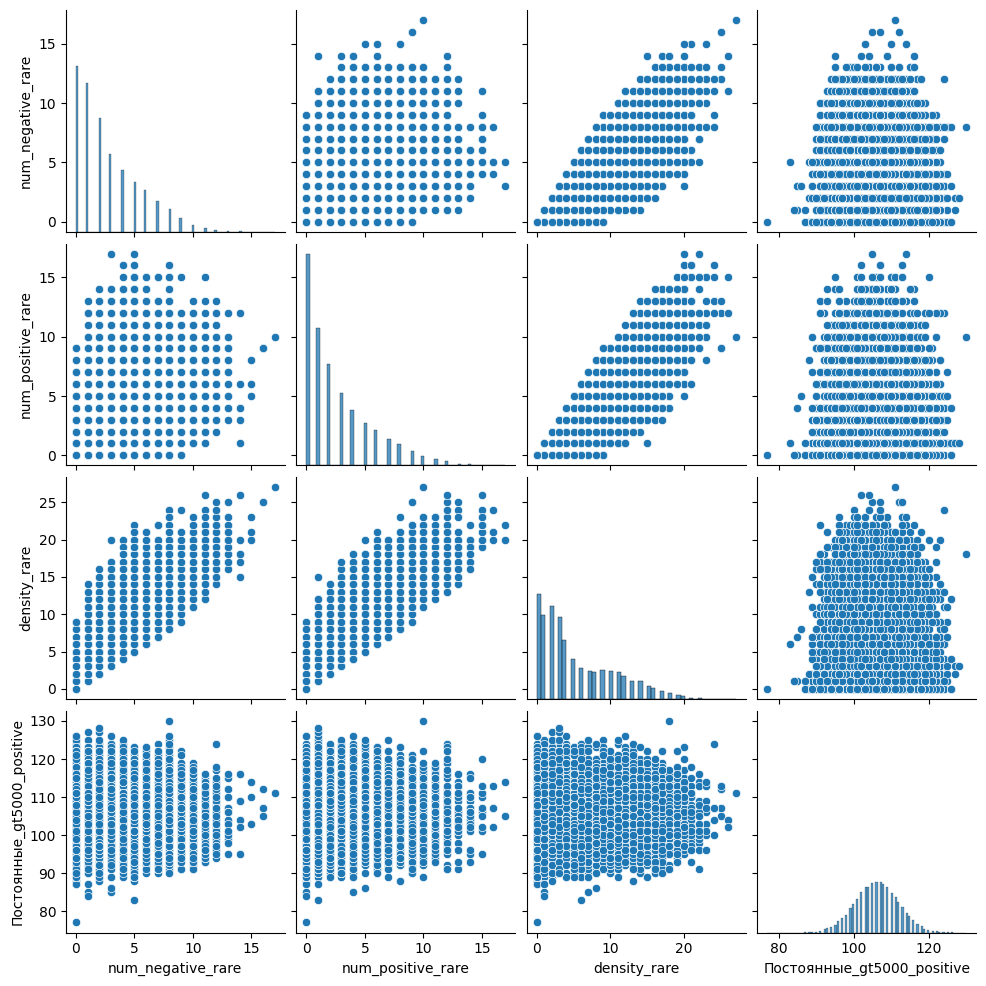

In [256]:
import seaborn as sns

sns.pairplot(top_cols[beam_cols])


In [257]:
top_cols[beam_cols].corr()


,num_negative_rare,num_positive_rare,density_rare,Постоянные_gt5000_positive
num_negative_rare,1.000000,0.634900,0.896707,-0.024870
num_positive_rare,0.634900,1.000000,0.911289,-0.021759
density_rare,0.896707,0.911289,1.000000,-0.025721
Постоянные_gt5000_positive,-0.024870,-0.021759,-0.025721,1.000000


In [264]:
df2_cols = ['Нечастые_251_2900_negative', 'Нечастые_251_2900_positive',
            'Нечастые_251_2900_nonzero', 'Постоянные_gt5000_negative',
            'Постоянные_gt5000_positive', 'Постоянные_gt5000_pos_to_neg_ratio',
            'Частые_2901_5000_negative', 'total_negative',
            'Частые_2901_5000_nonzero', 'Частые_2901_5000_positive',
            'total_positive', 'total_nonzero',
            'Нечастые_251_2900_pos_to_neg_ratio']

In [265]:
beam_df = top_cols[beam_cols].copy()
df2_selected = aggregated_features[df2_cols].copy()

full_scaled_features = pd.concat([beam_df, df2_selected], axis=1)

In [266]:
df2_selected["sum_pos_neg_rare"] = df2_selected["Нечастые_251_2900_positive"] + df2_selected["Нечастые_251_2900_negative"]
df2_selected["abs_diff_pos_neg_rare"] = (df2_selected["Нечастые_251_2900_positive"] - df2_selected["Нечастые_251_2900_negative"]).abs()
df2_selected["ratio_pos_neg_rare"] = df2_selected["Нечастые_251_2900_positive"] / (df2_selected["Нечастые_251_2900_negative"] + 1e-6)

df2_selected["interaction_density_pos"] = df2_selected["Нечастые_251_2900_nonzero"] * df2_selected["Постоянные_gt5000_positive"]
df2_selected["interaction_density_neg"] = df2_selected["Нечастые_251_2900_nonzero"] * df2_selected["Постоянные_gt5000_negative"]

df2_selected["rare_to_total_nonzero"] = df2_selected["Нечастые_251_2900_nonzero"] / (df2_selected["total_nonzero"] + 1e-6)


In [267]:
scaler = StandardScaler()
df2_scaled = pd.DataFrame(scaler.fit_transform(df2_selected), columns=df2_selected.columns)


In [284]:
beam_results_df2 = beam_search_hdbscan(df2_scaled)
beam_results_df2.sort_values("noise_pct")


KeyboardInterrupt: 

In [285]:
beam_results_df2 = beam_results_df2.sort_values("noise_pct")

beam_results_df2.head(20)

,features,silhouette,n_clusters,noise_pct
3,"(Нечастые_251_2900_nonzero,)",0.997066,22,0.000143
1,"(Нечастые_251_2900_negative,)",0.998159,13,0.000333
65,"(sum_pos_neg_rare, Нечастые_251_2900_nonzero)",0.998538,22,0.001095
0,"(abs_diff_pos_neg_rare,)",0.998794,10,0.002286
2,"(Нечастые_251_2900_positive,)",0.997210,13,0.004429
4,"(abs_diff_pos_neg_rare, Нечастые_251_2900_nega...",0.929388,60,0.007905
149,"(abs_diff_pos_neg_rare, rare_to_total_nonzero,...",0.890296,59,0.010095
164,"(abs_diff_pos_neg_rare, rare_to_total_nonzero,...",0.890296,59,0.010095
209,"(abs_diff_pos_neg_rare, rare_to_total_nonzero,...",0.898027,59,0.010429
16,"(abs_diff_pos_neg_rare, Нечастые_251_2900_pos_...",0.948472,74,0.011762


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kpolekhina/Do

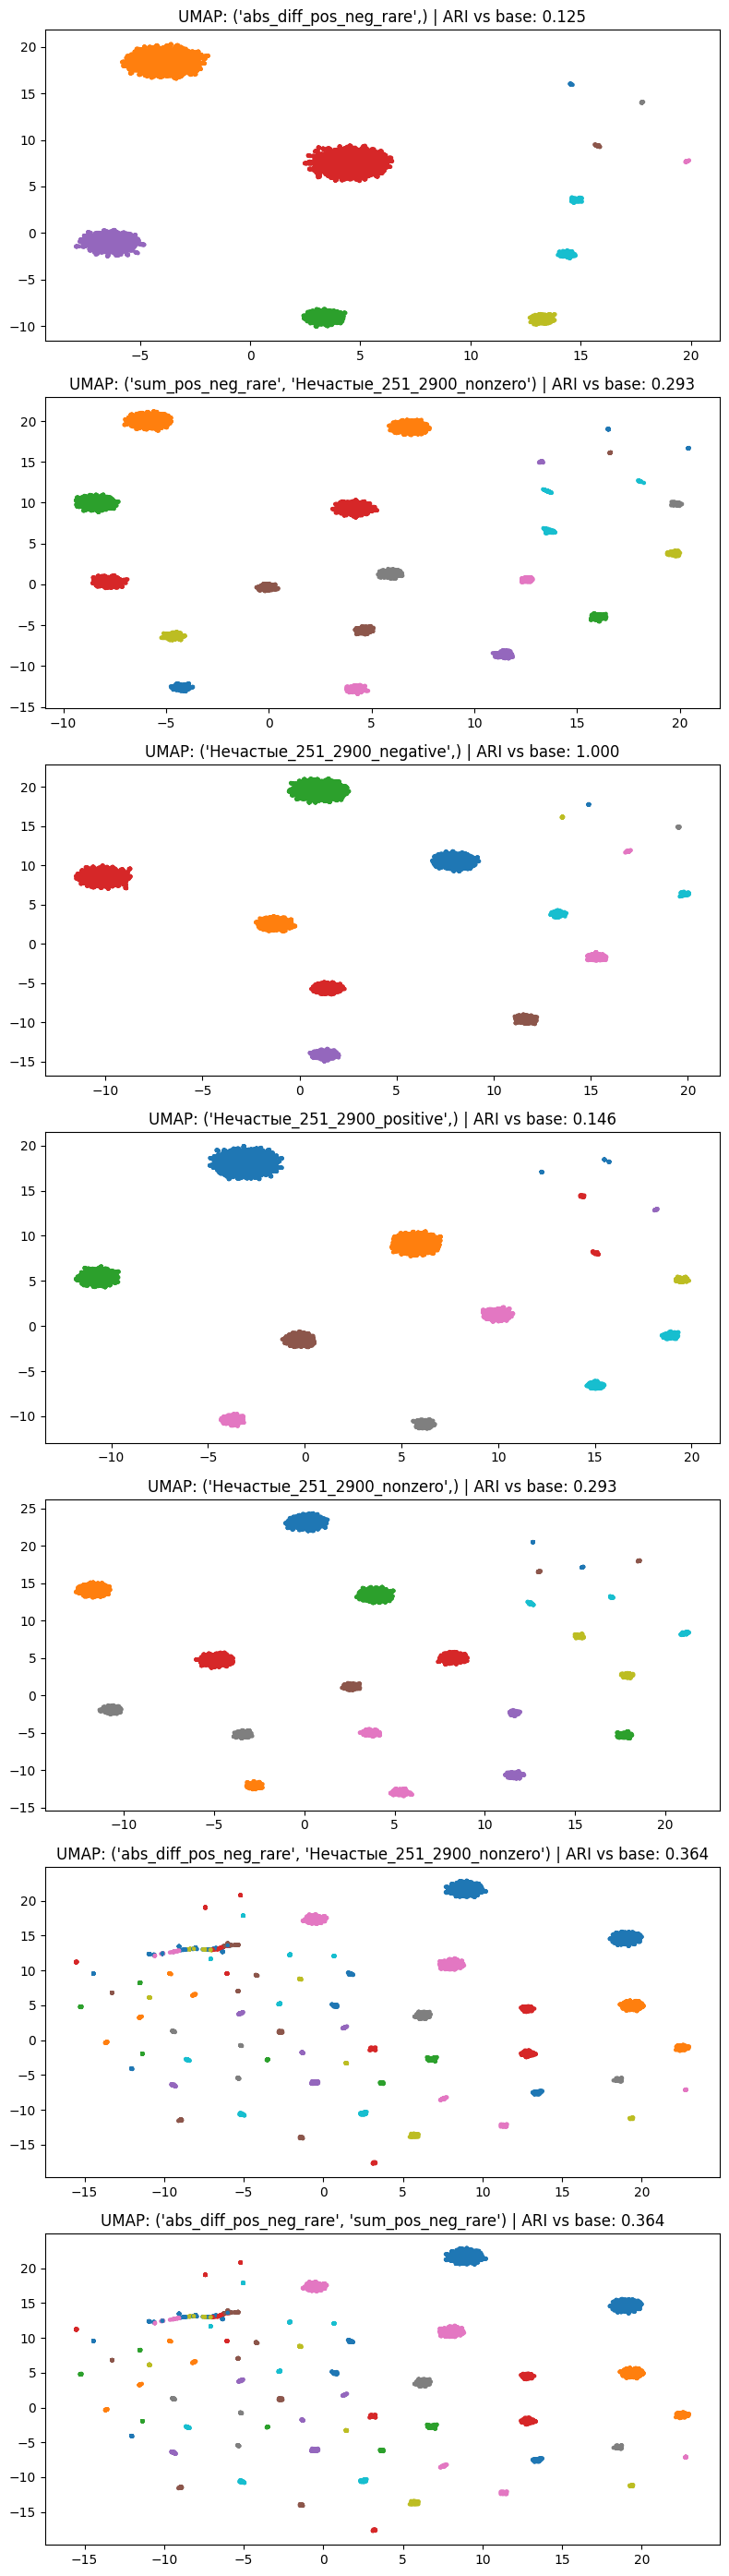

In [275]:
from sklearn.metrics import adjusted_rand_score

top_combinations = [
    ("abs_diff_pos_neg_rare",),
    ("sum_pos_neg_rare", "Нечастые_251_2900_nonzero"),
    ("Нечастые_251_2900_negative",),
    ("Нечастые_251_2900_positive",),
    ("Нечастые_251_2900_nonzero",),
    ("abs_diff_pos_neg_rare", "Нечастые_251_2900_nonzero"),
    ("abs_diff_pos_neg_rare", "sum_pos_neg_rare"),
]

cluster_results = {}
base_labels = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(initial_feature_df[["num_negative_rare"]].values)

ari_matrix = []
fig, axs = plt.subplots(len(top_combinations), 1, figsize=(8, len(top_combinations) * 4))

for i, features in enumerate(top_combinations):
    X_subset = df2_selected[list(features)].values

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
    X_umap = reducer.fit_transform(X_subset)

    labels = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(X_subset)

    cluster_results[features] = {
        "labels": labels,
        "umap": X_umap
    }

    # ARI с базой
    ari_base = adjusted_rand_score(base_labels, labels)
    ari_matrix.append({
        "features_1": features,
        "features_2": ("num_negative_rare",),
        "ARI": ari_base
    })

    # Визуализация
    axs[i].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab10", s=5)
    axs[i].set_title(f"UMAP: {features} | ARI vs base: {ari_base:.3f}")

plt.tight_layout()


In [276]:
ari_df = pd.DataFrame(ari_matrix)
ari_df

,features_1,features_2,ARI
0,"(abs_diff_pos_neg_rare,)","(num_negative_rare,)",0.125102
1,"(sum_pos_neg_rare, Нечастые_251_2900_nonzero)","(num_negative_rare,)",0.293148
2,"(Нечастые_251_2900_negative,)","(num_negative_rare,)",1.000000
3,"(Нечастые_251_2900_positive,)","(num_negative_rare,)",0.145618
4,"(Нечастые_251_2900_nonzero,)","(num_negative_rare,)",0.293148
5,"(abs_diff_pos_neg_rare, Нечастые_251_2900_nonz...","(num_negative_rare,)",0.363531
6,"(abs_diff_pos_neg_rare, sum_pos_neg_rare)","(num_negative_rare,)",0.363531


In [277]:
labels_1 = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(df2_selected[["abs_diff_pos_neg_rare"]].values)

labels_2 = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5).fit_predict(
    df2_selected[["sum_pos_neg_rare", "Нечастые_251_2900_nonzero"]].values
)

In [279]:
def noise_stats(labels):
    total = len(labels)
    noise = np.sum(labels == -1)
    noise_pct = noise / total
    print(f"Noise points: {noise} ({noise_pct:.4%})")
    return noise, noise_pct

noise_stats(labels_1)
noise_stats(labels_2)


Noise points: 48 (0.2286%)
Noise points: 1 (0.0048%)


(np.int64(1), np.float64(4.761904761904762e-05))

In [281]:
from sklearn.neighbors import NearestNeighbors

def assign_noise_to_nearest_cluster(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)
    noise_mask = labels == -1
    if not np.any(noise_mask):
        return labels

    non_noise_X = X[~noise_mask]
    non_noise_labels = labels[~noise_mask]

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(non_noise_X)
    _, indices = nn.kneighbors(X[noise_mask])
    assigned_labels = non_noise_labels[indices[:, 0]]

    new_labels = labels.copy()
    new_labels[noise_mask] = assigned_labels
    return new_labels

X_subset_2 = df2_selected[["sum_pos_neg_rare", "Нечастые_251_2900_nonzero"]].values
labels_2_fixed = assign_noise_to_nearest_cluster(X_subset_2, labels_2)
noise_stats(labels_2_fixed)


Noise points: 0 (0.0000%)


(np.int64(0), np.float64(0.0))

In [ ]:
submission = pd.DataFrame({
    'ID': np.arange(len(labels_2_fixed)),
    'TARGET': labels_2_fixed
})

submission.to_csv('no_more_hahas_submission.csv', index=False)

In [287]:
source_map = {
    "density_rare": initial_feature_df,
    "Нечастые_251_2900_negative": aggregated_features,
    "Постоянные_gt5000_positive": aggregated_features,
    "Постоянные_gt5000_negative": aggregated_features,
    "total_negative": aggregated_features
}

results = []

for feat, df in source_map.items():
    X_feat = df[[feat]].values
    clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
    labels = clusterer.fit_predict(X_feat)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels)
    ari = adjusted_rand_score(labels_2_fixed, labels)

    results.append({
        "feature": feat,
        "ARI vs best": round(ari, 6),
        "n_clusters": n_clusters,
        "noise_pct": round(noise_pct, 6)
    })

results_df = pd.DataFrame(results)
results_df

,feature,ARI vs best,n_clusters,noise_pct
0,density_rare,0.999998,22,0.000048
1,Нечастые_251_2900_negative,0.293148,13,0.001667
2,Постоянные_gt5000_positive,0.000066,31,0.000571
3,Постоянные_gt5000_negative,0.000061,32,0.001571
4,total_negative,0.001065,60,0.000476


In [290]:
ari = adjusted_rand_score(labels_2_fixed, labels_1)
ari

0.2813805354763461

вывод из лучших скоров: пока работали количественные признаки на знаках....

In [ ]:
df2_selected["sum_nonzero_pos_neg"] = (
    df2_selected["Нечастые_251_2900_positive"] +
    df2_selected["Нечастые_251_2900_negative"] +
    df2_selected["Нечастые_251_2900_nonzero"]
)

df2_selected["nonzero_plus_ratio"] = (
    df2_selected["Нечастые_251_2900_nonzero"] +
    df2_selected["ratio_pos_neg_rare"]
)

df2_selected["log_sum_combo"] = np.log1p(
    df2_selected["sum_pos_neg_rare"] +
    df2_selected["Нечастые_251_2900_nonzero"]
)

df2_selected["sum_pos_neg_ratio_weighted"] = (
    df2_selected["ratio_pos_neg_rare"] *
    df2_selected["sum_pos_neg_rare"]
)

df2_selected["nonzero_x_pos"] = (
    df2_selected["Нечастые_251_2900_nonzero"] *
    df2_selected["Нечастые_251_2900_positive"]
)

df2_selected["nonzero_x_neg"] = (
    df2_selected["Нечастые_251_2900_nonzero"] *
    df2_selected["Нечастые_251_2900_negative"]
)


In [293]:
candidate_cols = [
    "sum_nonzero_pos_neg",
    "nonzero_plus_ratio",
    "log_sum_combo",
    "sum_pos_neg_ratio_weighted",
    "nonzero_x_pos",
    "nonzero_x_neg"
]

results = []
for col in candidate_cols:
    X = df2_selected[[col]].values
    clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
    labels = clusterer.fit_predict(X)
    ari = adjusted_rand_score(labels_2_fixed, labels)
    noise_pct = np.mean(labels == -1)
    n_clusters = len(np.unique(labels[labels != -1]))
    results.append({
        "feature": col,
        "ARI vs best": ari,
        "n_clusters": n_clusters,
        "noise_pct": noise_pct
    })

results_df = pd.DataFrame(results).sort_values("ARI vs best", ascending=False)
results_df

,feature,ARI vs best,n_clusters,noise_pct
0,sum_nonzero_pos_neg,0.999998,22,0.000048
2,log_sum_combo,0.999998,22,0.000048
1,nonzero_plus_ratio,0.646258,79,0.017333
5,nonzero_x_neg,0.495561,63,0.012524
3,sum_pos_neg_ratio_weighted,0.411030,75,0.014333
4,nonzero_x_pos,0.403871,62,0.009714


In [294]:
features_to_test = [
    "nonzero_plus_ratio",
    "nonzero_x_neg",
    "sum_pos_neg_ratio_weighted",
    "nonzero_x_pos"
]

min_cluster_sizes = range(30, 101, 10)
min_samples_list = [5, 10, 15]

results = []

for feat in features_to_test:
    X_feat = df2_selected[[feat]].values
    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_list:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
            labels = clusterer.fit_predict(X_feat)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_pct = (labels == -1).sum() / len(labels)
            sil_score = silhouette_score(X_feat, labels) if n_clusters > 1 else -1
            ari_vs_best = adjusted_rand_score(labels_2_fixed, labels)

            results.append({
                "feature": feat,
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_pct": round(noise_pct, 6),
                "silhouette": round(sil_score, 6),
                "ARI vs best": round(ari_vs_best, 6)
            })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["feature", "ARI vs best"], ascending=[True, False])

results_df

,feature,min_cluster_size,min_samples,n_clusters,noise_pct,silhouette,ARI vs best
0,nonzero_plus_ratio,30,5,99,0.012000,0.960850,0.649049
1,nonzero_plus_ratio,30,10,99,0.012048,0.960888,0.649045
2,nonzero_plus_ratio,30,15,98,0.014429,0.957975,0.648703
3,nonzero_plus_ratio,40,5,89,0.015381,0.952504,0.648056
4,nonzero_plus_ratio,40,10,89,0.015429,0.952541,0.648048
...,...,...,...,...,...,...,...
66,sum_pos_neg_ratio_weighted,90,5,58,0.025095,0.906273,0.408161
67,sum_pos_neg_ratio_weighted,90,10,58,0.025286,0.906282,0.408151
69,sum_pos_neg_ratio_weighted,100,5,54,0.038714,0.881009,0.406008
71,sum_pos_neg_ratio_weighted,100,15,54,0.038905,0.880997,0.406004


In [296]:
results_df = results_df.sort_values(by="noise_pct")
results_df


,feature,min_cluster_size,min_samples,n_clusters,noise_pct,silhouette,ARI vs best
24,nonzero_x_neg,30,5,75,0.004190,0.979768,0.496565
72,nonzero_x_pos,30,5,77,0.005000,0.974647,0.405110
25,nonzero_x_neg,30,10,74,0.007000,0.977677,0.496532
26,nonzero_x_neg,30,15,73,0.007762,0.976003,0.496527
73,nonzero_x_pos,30,10,76,0.007810,0.973620,0.405171
...,...,...,...,...,...,...,...
41,nonzero_x_neg,80,15,52,0.028048,0.917611,0.491934
22,nonzero_plus_ratio,100,10,60,0.029429,0.898295,0.641973
69,sum_pos_neg_ratio_weighted,100,5,54,0.038714,0.881009,0.406008
70,sum_pos_neg_ratio_weighted,100,10,54,0.038857,0.881018,0.405993


In [297]:
X_final = df2_selected[["nonzero_x_neg"]].values

final_clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=5)
labels_final = final_clusterer.fit_predict(X_final)

num_noise_points = np.sum(labels_final == -1)
print(f"Количество шумовых точек: {num_noise_points}")

Количество шумовых точек: 88


мой самый последний сабмит :) пусть "шум" останется одним кластером)

In [ ]:
# submission = pd.DataFrame({
#     'ID': np.arange(len(labels_final)),
#     'TARGET': labels_final
# })

# submission.to_csv('final_submission.csv', index=False)

штож, не вышло, не случилось)